In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import requests
from io import StringIO

warnings.filterwarnings('ignore')

In [ ]:
pd.options.display.max_columns=None

In [ ]:
pd.options.display.float_format = '{:.3f}'.format

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/Códigos atuais/Merge INMET_ANA-SISAGUA - 60km_10km.parquet')
df.head()

,Região Geográfica,UF,Município,Código IBGE,Date,Date_SISAGUA,Categoria do manancial superficial,Unidade,Resultado,Nome_Rio_sisagua,Estacao_Codigo_split,Nome_Municipio,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Ano,Clorofila,ODsaturacao,DescargaLiquida,OrtofosfatoTotal,Latitude,Longitude,Altitude,Classe,station_id,data_inmet,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,fase,match_encontrado
0,SUDESTE,SP,PIRAJU,353880,2017-05-19,2017-05-25,rio,Aphanocapsa sp.,59.000,RIO PARANAPANEMA,21389000,PIRAJU,0.920,18.000,21.000,7.420,NaN,NaN,NaN,3.000,NaN,NaN,NaN,NaN,0.700,NaN,NaN,0.010,2017,0.010,NaN,NaN,NaN,-23.160,-49.368,531.000,0,306.000,2017-05-19,47561.449,55.400,78.200,121.375,923.837,RAIO_60KM,True
1,SUDESTE,SP,PIRACAIA,353860,2017-09-11,2017-09-25,rio,Cylindrospermopsis sp.,18774.000,RIO DA CACHOEIRA,21387000,PIRACAIA,NaN,NaN,21.500,6.400,9.000,NaN,NaN,2.000,7.200,NaN,100.000,100.000,NaN,0.500,NaN,NaN,2017,NaN,NaN,NaN,NaN,-23.095,-46.442,760.000,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,SEM_MATCH,False
2,SUDESTE,SP,PIRACAIA,353860,2017-09-14,2017-09-25,rio,Cylindrospermopsis sp.,18774.000,RIO DA CACHOEIRA,21387000,PIRACAIA,NaN,NaN,22.620,7.680,2.500,NaN,NaN,3.000,10.100,NaN,100.000,100.000,NaN,0.100,NaN,NaN,2017,NaN,NaN,NaN,NaN,-23.034,-46.290,826.000,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,SEM_MATCH,False
3,SUDESTE,SP,PIRACAIA,353860,2017-09-21,2017-09-25,rio,Cylindrospermopsis sp.,18774.000,RIO DA CACHOEIRA,21387000,PIRACAIA,0.680,27.000,20.410,8.620,4.300,NaN,45.100,NaN,7.260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,NaN,88.900,NaN,NaN,-23.052,-46.365,788.000,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,SEM_MATCH,False
4,SUDESTE,SP,PIRACAIA,353860,2017-09-21,2017-09-25,rio,Cylindrospermopsis sp.,18774.000,RIO DA CACHOEIRA,21387000,PIRACAIA,0.720,27.000,20.400,8.490,4.900,NaN,44.900,NaN,7.260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,NaN,88.700,NaN,NaN,-23.052,-46.365,788.000,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,SEM_MATCH,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Região Geográfica                   12449 non-null  object        
 1   UF                                  12449 non-null  object        
 2   Município                           12449 non-null  object        
 3   Código IBGE                         12449 non-null  int64         
 4   Date                                12449 non-null  datetime64[ns]
 5   Date_SISAGUA                        12449 non-null  datetime64[ns]
 6   Categoria do manancial superficial  12449 non-null  object        
 7   Unidade                             12449 non-null  object        
 8   Resultado                           12449 non-null  float64       
 9   Nome_Rio_sisagua                    12449 non-null  object        
 10  Estacao_Codigo_split  

In [ ]:
col_sisagua = 'Date_SISAGUA'
col_ana = 'Date'
col_diff_td = 'Diferenca_Tempo' # Nome da coluna timedelta
col_diff_days = 'Diferenca_Dias_Num' # Nome da nova coluna numérica

# Converta as colunas para datetime
df[col_sisagua + '_dt'] = pd.to_datetime(df[col_sisagua], errors='coerce')
df[col_ana + '_dt'] = pd.to_datetime(df[col_ana], errors='coerce')

# Calcule a diferença (Timedelta)
df[col_diff_td] = df[col_sisagua + '_dt'] - df[col_ana + '_dt']

# Extraia apenas o número de dias da coluna Timedelta
#    O resultado será um número (float se houver NaNs, caso contrário pode ser int)
df[col_diff_days] = df[col_diff_td].dt.days

# Remover colunas temporárias se não precisar mais delas
df = df.drop(columns=[col_sisagua + '_dt', col_ana + '_dt', col_diff_td, 'Diferenca_Tempo'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 47 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Região Geográfica                   12449 non-null  object        
 1   UF                                  12449 non-null  object        
 2   Município                           12449 non-null  object        
 3   Código IBGE                         12449 non-null  int64         
 4   Date                                12449 non-null  datetime64[ns]
 5   Date_SISAGUA                        12449 non-null  datetime64[ns]
 6   Categoria do manancial superficial  12449 non-null  object        
 7   Unidade                             12449 non-null  object        
 8   Resultado                           12449 non-null  float64       
 9   Nome_Rio_sisagua                    12449 non-null  object        
 10  Estacao_Codigo_split  

In [ ]:
threshold = 0
counts_classe1 = df[df['Classe'] == 1]['Unidade'].value_counts()
unidades_com_1 = counts_classe1[counts_classe1 >= threshold].index.tolist()
df_filtrado = df[df['Unidade'].isin(unidades_com_1)].copy()
pivot_result = df_filtrado.pivot_table(
    index='Diferenca_Dias_Num',
    columns=['Classe', 'Unidade'],
    aggfunc='size'
).reset_index()
pivot_result

Classe  Diferenca_Dias_Num            0                                  \
Unidade                    Anabaena sp. Aphanocapsa sp. Aphanothece sp.   
0                        1       22.000         100.000           5.000   
1                        2       12.000          71.000           3.000   
2                        3       17.000          49.000          15.000   
3                        4       16.000         111.000          11.000   
4                        5       28.000         134.000           7.000   
5                        6       41.000         181.000          12.000   
6                        7       36.000         166.000           9.000   
7                        8       30.000          93.000           7.000   
8                        9       19.000          70.000          10.000   
9                       10       18.000          43.000           9.000   
10                      11       12.000          77.000          10.000   
11                      12       24.000         111.000          11.000   
12                      13       19.000         220.000          15.000   
13                      14       28.000         192.000          12.000   

Classe                                                              \
Unidade Cylindrospermopsis sp. Dolichospermum sp. Geitlerinema sp.   
0                      110.000             41.000          136.000   
1                       78.000             35.000           87.000   
2                       41.000             13.000           42.000   
3                       97.000             65.000           45.000   
4                       99.000             56.000           95.000   
5                      163.000             90.000          159.000   
6                      152.000             77.000          159.000   
7                      115.000             42.000          122.000   
8                       56.000             37.000           90.000   
9                       53.000             16.000           36.000   
10                      84.000             40.000           62.000   
11                     126.000             50.000           94.000   
12                     184.000            111.000          144.000   
13                     186.000             76.000          164.000   

Classe                                                                        \
Unidade Microcystis sp. Oscillatoria sp. Planktolyngbya sp. Planktothrix sp.   
0                73.000            2.000             27.000           42.000   
1                49.000              NaN             19.000           14.000   
2                42.000              NaN             13.000           15.000   
3                65.000              NaN             14.000           26.000   
4                95.000              NaN             14.000           55.000   
5               110.000              NaN             27.000           50.000   
6               104.000              NaN             31.000           39.000   
7                60.000            1.000             17.000           43.000   
8                42.000              NaN             23.000           24.000   
9                31.000              NaN             14.000           21.000   
10               58.000              NaN             21.000           24.000   
11               78.000            2.000             17.000           33.000   
12              137.000            1.000             37.000           47.000   
13               89.000              NaN             60.000           50.000   

Classe                                                 1                  \
Unidade Pseudoanabaena sp. Raphidiopsis sp. Anabaena sp. Aphanocapsa sp.   
0                  100.000           18.000        1.000          18.000   
1                   49.000            9.000        3.000          10.000   
2                   52.000            6.000        1.000           3.000   
3                

In [ ]:
df_agregado = df.copy()

In [ ]:
df_x = df_agregado[(df_agregado['Diferenca_Dias_Num']>4)&(df_agregado['RADIACAO_MEDIA_DIARIA']>0)&(df_agregado['match_encontrado']==True)]
df_x.describe()

,Código IBGE,Date,Date_SISAGUA,Resultado,Estacao_Codigo_split,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Ano,Clorofila,ODsaturacao,DescargaLiquida,OrtofosfatoTotal,Latitude,Longitude,Altitude,Classe,station_id,data_inmet,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num
count,6952.000,6952,6952,6952.000,6952.000,2537.000,5389.000,6285.000,6240.000,5619.000,912.000,4676.000,4901.000,6139.000,3243.000,3308.000,4553.000,2566.000,3941.000,3671.000,4369.000,6952.000,4117.000,1916.000,531.000,2422.000,6952.000,6952.000,3740.000,6952.000,6952.000,6952,6952.000,6952.000,6952.000,6952.000,6952.000,6952.000
mean,320632.218,2019-03-15 16:46:28.032221184,2019-03-25 06:45:46.605293312,12302.929,18155663.708,1.248,27.200,25.349,7.279,27.480,1527.464,759.107,5.648,6.614,377.773,232.859,661.616,1.672,1.349,0.477,0.191,2018.719,20.696,80.818,107.322,0.100,-17.247,-44.554,458.251,0.167,509.342,2019-03-15 16:46:28.032221184,32931.717,737.324,3.417,143.455,926.571,9.583
min,110002.000,2015-04-15 00:00:00,2015-04-23 00:00:00,1.000,1001000.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2015.000,0.000,0.000,0.000,0.000,-31.574,-63.240,-1.000,0.000,23.000,2015-04-15 00:00:00,354.116,0.067,0.000,0.000,0.000,5.000
25%,290485.000,2018-01-10 00:00:00,2018-01-22 00:00:00,72.000,16119000.000,0.200,25.000,22.990,6.800,3.200,68.480,64.200,2.000,5.360,70.000,50.000,59.000,1.000,0.200,0.020,0.020,2018.000,1.100,69.100,0.143,0.020,-22.752,-48.041,328.000,0.000,145.000,2018-01-10 00:00:00,21258.765,572.229,0.000,100.146,931.012,7.000
50%,350570.000,2018-10-05 00:00:00,2018-10-17 00:00:00,844.000,21057000.000,0.300,28.000,25.900,7.300,7.950,126.400,107.000,3.000,6.600,112.000,50.000,100.000,1.000,0.400,0.140,0.042,2018.000,2.100,81.100,8.990,0.020,-20.176,-46.337,474.000,0.000,410.000,2018-10-05 00:00:00,33448.778,744.360,0.000,141.583,961.000,9.000
75%,353860.000,2020-02-07 00:00:00,2020-02-19 00:00:00,5312.000,21369000.000,0.640,30.200,28.200,7.840,22.000,284.200,285.400,4.000,7.750,224.000,100.000,190.000,1.540,0.440,0.500,0.185,2020.000,10.690,92.200,81.998,0.020,-12.586,-40.184,652.500,0.000,909.000,2020-02-07 00:00:00,44371.694,938.188,1.400,188.542,989.012,13.000
max,521940.000,2023-11-14 00:00:00,2023-11-22 00:00:00,2648208.000,29121000.000,77.000,41.300,37.870,83.400,2765.000,73400.000,69888.000,485.000,290.000,59058.000,100000.000,47342.000,28.000,30.100,17.100,15.000,2023.000,7410.000,852.400,5541.430,7.090,-3.054,-34.916,1287.000,1.000,1273.000,2023-11-14 00:00:00,59986.211,1852.487,78.200,360.000,1028.342,14.000
std,58528.145,NaN,NaN,79117.378,4741868.641,4.426,5.251,4.165,2.003,75.551,8848.496,5375.516,13.594,7.304,2033.971,3368.954,4196.356,2.151,3.688,1.155,0.497,1.538,233.124,43.167,394.919,0.303,7.014,4.573,232.262,0.373,346.967,NaN,14269.557,264.576,8.845,66.294,151.494,3.150


In [ ]:
df_x.columns

Index(['Região Geográfica', 'UF', 'Município', 'Código IBGE', 'Date',
       'Date_SISAGUA', 'Categoria do manancial superficial', 'Unidade',
       'Resultado', 'Nome_Rio_sisagua', 'Estacao_Codigo_split',
       'Nome_Municipio', 'Profundidade', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'CondutividadeEletrica', 'CondutividadeEspecifica', 'DBO',
       'OD', 'SolTotais', 'SolSuspensaoTotais', 'SolDissolvidosTotais',
       'NitrogenioTotal', 'NitrogenioAmoniacal', 'Nitratos', 'FosforoTotal',
       'Ano', 'Clorofila', 'ODsaturacao', 'DescargaLiquida',
       'OrtofosfatoTotal', 'Latitude', 'Longitude', 'Altitude', 'Classe',
       'station_id', 'data_inmet', 'distancia_m', 'RADIACAO_MEDIA_DIARIA',
       'PRECIPITACAO_SOMA_DIARIA', 'VENTO_MEDIA_DIARIA',
       'PRESSAO_MEDIA_DIARIA', 'fase', 'match_encontrado',
       'Diferenca_Dias_Num'],
      dtype='object')

In [ ]:
df_x['Unidade'].unique()

array(['Aphanocapsa sp.', 'Cylindrospermopsis sp.', 'Dolichospermum sp.',
       'Planktothrix sp.', 'Pseudoanabaena sp.', 'Geitlerinema sp.',
       'Microcystis sp.', 'Raphidiopsis sp.', 'Planktolyngbya sp.',
       'Synechocystis sp.', 'Aphanothece sp.', 'Anabaena sp.',
       'Synechococcus sp.', 'Lyngbya sp.', 'Radiocystis sp.',
       'Jaaginema sp.', 'Tychonema sp.', 'Sphaeropermopsis sp.'],
      dtype=object)

# CÓDIGO TESTE

In [ ]:
# ==============================================================================
# SELEÇÃO DE CLASSES: APHANOCAPSA DOMINANTE vs. NÃO-FLORAÇÃO (ATUALIZADO)
# ==============================================================================
print("🧬 ESTRATÉGIA ATUALIZADA: Aphanocapsa dominante vs. Não-Floração")
print("📊 NOVOS CRITÉRIOS:")
print("   Classe 1: Floração com Aphanocapsa dominante")
print("     1. Total de cianobactérias > 20.000 cél/mL (floração)")
print("     2. Aphanocapsa > soma de todas as outras cianobactérias (dominância)")
print("     3. Aphanocapsa >= 1 cél/mL")
print("\n   Classe 0: SEM floração (qualquer gênero)")
print("     1. Total de cianobactérias <= 20.000 cél/mL")
print("\n⚠️  IMPORTANTE: Amostras diferentes têm combinações únicas de (Local, Date, Date_SISAGUA)")
print("   Recoletas = duplicatas exatas de (Local, Date, Date_SISAGUA, Unidade)")

# ==============================================================================
# 1. VERIFICAR ESTRUTURA DOS DADOS
# ==============================================================================
print("\n1. 📋 Verificando estrutura dos dados...")
print(f"Shape inicial do df_x: {df_x.shape}")
print(f"Gêneros disponíveis na coluna 'Unidade':")
unidade_counts = df_x['Unidade'].value_counts()
print(unidade_counts)

# Verificar se Aphanocapsa existe
aphanocapsa_samples = df_x['Unidade'].str.contains('Aphanocapsa', case=False, na=False).sum()
print(f"\n✅ Amostras com Aphanocapsa: {aphanocapsa_samples}")

# ==============================================================================
# 1.5. TRATAR DUPLICATAS VERDADEIRAS (NÃO RECOLETAS)
# ==============================================================================
print("\n1.5. 🔄 Tratando duplicatas verdadeiras (não confundir com recoletas)...")

# Converter datas para datetime se necessário
if 'Date' in df_x.columns and df_x['Date'].dtype == 'object':
    df_x['Date'] = pd.to_datetime(df_x['Date'], errors='coerce')

if 'Date_SISAGUA' in df_x.columns and df_x['Date_SISAGUA'].dtype == 'object':
    df_x['Date_SISAGUA'] = pd.to_datetime(df_x['Date_SISAGUA'], errors='coerce')

# Verificar duplicatas VERDADEIRAS (mesma combinação de Local + Date + Date_SISAGUA + Unidade)
duplicatas_antes = df_x.duplicated(subset=['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Unidade'], keep=False).sum()
print(f"   📊 Registros duplicados VERDADEIROS (mesmo local-date-date_sisagua-unidade): {duplicatas_antes}")

if duplicatas_antes > 0:
    # Ordenar para pegar sempre o registro mais recente em caso de duplicata verdadeira
    # (usando alguma coluna de controle, se houver, ou simplesmente o último registro)
    df_x_sorted = df_x.sort_values(['Latitude', 'Longitude','Date', 'Date_SISAGUA', 'Unidade']).copy()

    # Manter apenas a ÚLTIMA ocorrência de duplicatas verdadeiras
    df_x_clean = df_x_sorted.drop_duplicates(
        subset=['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Unidade'],
        keep='last'
    )

    duplicatas_depois = df_x_clean.duplicated(subset=['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Unidade'], keep=False).sum()
    print(f"   ✅ Registros duplicados após limpeza: {duplicatas_depois}")
    print(f"   ✅ Registros removidos (duplicatas): {len(df_x) - len(df_x_clean)}")

    df_x = df_x_clean.copy()
else:
    print("   ✅ Nenhuma duplicata verdadeira encontrada!")

# Mostrar estatísticas de combinações únicas
combinacoes_unicas = df_x.groupby(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA']).size()
print(f"\n   📊 Combinações únicas de (Local, Date, Date_SISAGUA): {len(combinacoes_unicas)}")
print(f"   📊 Total de registros após limpeza: {len(df_x)}")

# ==============================================================================
# 2. CRIAR COLUNA UNIDADE_CONJUNTA COM GÊNEROS POR LOCAL-DATA-DATA_SISAGUA
# ==============================================================================
print("\n2. 🔗 Criando coluna 'Unidade_Conjunta'...")

# Agrupar gêneros por local-date-date_sisagua (amostras únicas)
df_generos_por_local = df_x.groupby(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA']).agg({
    'Unidade': lambda x: ', '.join(sorted(x.unique()))
}).reset_index()

df_generos_por_local.rename(columns={'Unidade': 'Unidade_Conjunta'}, inplace=True)
print(f"✅ Amostras únicas identificadas: {len(df_generos_por_local)}")

# ==============================================================================
# 3. CALCULAR TOTAIS POR AMOSTRA (LOCAL-DATE-DATE_SISAGUA)
# ==============================================================================
print("\n3. 📊 Calculando totais por amostra...")

# Agrupar por local-date-date_sisagua e calcular médias/somas
df_totais = df_x.groupby(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA']).agg({
    'Resultado': 'sum',  # Total de cianobactérias
    # Variáveis categóricas/fixas
    'Região Geográfica': 'first', 'UF': 'first', 'Município': 'first',
    'Código IBGE': 'first', 'Categoria do manancial superficial': 'first',
    'Nome_Rio_sisagua': 'first', 'Estacao_Codigo_split': 'first',
    'Nome_Municipio': 'first', 'Ano': 'first', 'Altitude': 'first',
    'station_id': 'first', 'data_inmet': 'first', 'fase': 'first',
    'match_encontrado': 'first',
    # Variáveis numéricas - usar média
    'Profundidade': 'mean', 'TempAr': 'mean', 'TempAmostra': 'mean',
    'pH': 'mean', 'Turbidez': 'mean', 'CondutividadeEletrica': 'mean',
    'CondutividadeEspecifica': 'mean', 'DBO': 'mean', 'OD': 'mean',
    'SolTotais': 'mean', 'SolSuspensaoTotais': 'mean', 'SolDissolvidosTotais': 'mean',
    'NitrogenioTotal': 'mean', 'NitrogenioAmoniacal': 'mean', 'Nitratos': 'mean',
    'FosforoTotal': 'mean', 'Clorofila': 'mean', 'ODsaturacao': 'mean',
    'DescargaLiquida': 'mean', 'OrtofosfatoTotal': 'mean', 'distancia_m': 'mean',
    'RADIACAO_MEDIA_DIARIA': 'mean', 'PRECIPITACAO_SOMA_DIARIA': 'mean',
    'VENTO_MEDIA_DIARIA': 'mean', 'PRESSAO_MEDIA_DIARIA': 'mean', 'Diferenca_Dias_Num': 'mean'
}).reset_index()

# Renomear coluna para clareza
df_totais.rename(columns={'Resultado': 'Total_Cianobacterias'}, inplace=True)

# Adicionar a coluna Unidade_Conjunta
df_totais = df_totais.merge(df_generos_por_local,
                            on=['Latitude', 'Longitude', 'Date', 'Date_SISAGUA'],
                            how='left')

# Adicionar coluna com número de gêneros
df_totais['Num_Generos'] = df_totais['Unidade_Conjunta'].str.count(',') + 1
print(f"✅ Amostras únicas processadas: {len(df_totais)}")

# ==============================================================================
# 4. CALCULAR CONTAGEM DE APHANOCAPSA POR AMOSTRA
# ==============================================================================
print("\n4. 🦠 Calculando Aphanocapsa por amostra...")
df_aphanocapsa_subset = df_x[df_x['Unidade'].str.contains('Aphanocapsa', case=False, na=False)]

df_aphanocapsa_totais = df_aphanocapsa_subset.groupby(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA']).agg({
    'Resultado': 'sum'
}).reset_index()
df_aphanocapsa_totais.rename(columns={'Resultado': 'Aphanocapsa_Count'}, inplace=True)
print(f"✅ Amostras com Aphanocapsa: {len(df_aphanocapsa_totais)}")

# ==============================================================================
# 5. MERGE DE TODOS OS DADOS E CÁLCULO DE 'OUTRAS'
# ==============================================================================
print("\n5. 🔗 Combinando todos os dados e calculando 'Outras Cianobactérias'...")

df_combined = df_totais.merge(df_aphanocapsa_totais,
                              on=['Latitude', 'Longitude', 'Date', 'Date_SISAGUA'],
                              how='left')

# Preencher NaN com 0 (locais sem Aphanocapsa)
df_combined['Aphanocapsa_Count'] = df_combined['Aphanocapsa_Count'].fillna(0)

# Calcular outras cianobactérias (exceto Aphanocapsa) como DIFERENÇA
df_combined['Outras_Cianobacterias'] = df_combined['Total_Cianobacterias'] - df_combined['Aphanocapsa_Count']
print(f"✅ Colunas 'Aphanocapsa_Count' e 'Outras_Cianobacterias' criadas.")

# ==============================================================================
# 6. APLICAR CRITÉRIOS DE SELEÇÃO ATUALIZADOS
# ==============================================================================
print("\n6. 🎯 Aplicando critérios de seleção atualizados...")

# --- CRITÉRIOS PARA CLASSE 1 (Aphanocapsa dominante em floração) ---
floracao_mask = df_combined['Total_Cianobacterias'] > 20000
dominancia_mask = df_combined['Aphanocapsa_Count'] > df_combined['Outras_Cianobacterias']
aphanocapsa_presente_mask = df_combined['Aphanocapsa_Count'] >= 1
classe_1_mask = floracao_mask & dominancia_mask & aphanocapsa_presente_mask

# --- CRITÉRIOS PARA CLASSE 0 (Não-floração - QUALQUER GÊNERO) ---
# Total de cianobactérias <= 20.000 (não precisa ter Aphanocapsa)
classe_0_mask = df_combined['Total_Cianobacterias'] <= 20000

print(f"   Resultados para Classe 1 (Aphanocapsa dominante em floração):")
print(f"     🎯 TOTAL CLASSE 1: {classe_1_mask.sum()}")

print(f"\n   Resultados para Classe 0 (Não-floração - qualquer gênero):")
print(f"     🎯 TOTAL CLASSE 0: {classe_0_mask.sum()}")


# ==============================================================================
# 7. CRIAR DATASET FINAL COM AS NOVAS CLASSES
# ==============================================================================
print("\n7. 📋 Criando dataset final com as novas regras...")

# Classe 1: Aphanocapsa dominante em floração
df_classe_1 = df_combined[classe_1_mask].copy()
df_classe_1['Classe'] = 1

# Classe 0: Sem floração (qualquer gênero)
df_classe_0 = df_combined[classe_0_mask].copy()
df_classe_0['Classe'] = 0

# Combinar as duas classes
df_classificado_final = pd.concat([df_classe_1, df_classe_0], ignore_index=True)

print(f"📊 DATASET FINAL (regras atualizadas):")
print(f"   Classe 1 (Aphanocapsa dominante em floração): {len(df_classe_1)}")
print(f"   Classe 0 (Sem floração - qualquer gênero): {len(df_classe_0)}")
print(f"   Total de amostras classificadas: {len(df_classificado_final)}")

# ==============================================================================
# 8. VERIFICAÇÃO FINAL COM FUNÇÃO ATUALIZADA
# ==============================================================================
print("\n8. ✅ Verificação final com função atualizada...")

def definir_classe_final_atualizada(row):
    total_ciano = row['Total_Cianobacterias']
    aphanocapsa = row['Aphanocapsa_Count']
    outras = row['Outras_Cianobacterias']

    # Regra para Classe 1: Aphanocapsa dominante EM floração + presente
    if total_ciano > 20000 and aphanocapsa > outras and aphanocapsa >= 1:
        return 1

    # Regra para Classe 0: Sem floração (qualquer gênero)
    elif total_ciano <= 20000:
        return 0

    # Casos que não se encaixam em nenhuma classe (floração sem Aphanocapsa dominante)
    else:
        return -1

# Aplicar a nova função de verificação
df_classificado_final['Classe_Verificada'] = df_classificado_final.apply(definir_classe_final_atualizada, axis=1)

# Verificar se a coluna original 'Classe' bate com a 'Classe_Verificada'
erros_verificacao = (df_classificado_final['Classe'] != df_classificado_final['Classe_Verificada']).sum()
if erros_verificacao == 0:
    print("✅ Verificação cruzada bem-sucedida! A lógica está consistente.")
else:
    print(f"❌ ATENÇÃO: {erros_verificacao} erros encontrados na verificação cruzada!")


# Remover casos inválidos (-1), se houver
casos_invalidos = (df_classificado_final['Classe_Verificada'] == -1).sum()
if casos_invalidos > 0:
    print(f"⚠️ Casos inválidos a serem removidos: {casos_invalidos}")


# Dataset final limpo
df_final_para_ml = df_classificado_final[df_classificado_final['Classe_Verificada'] != -1].copy()
# Renomear a coluna para o uso final
df_final_para_ml.rename(columns={'Classe_Verificada': 'Classe_final'}, inplace=True)
df_final_para_ml.drop(columns=['Classe'], inplace=True) # Remover coluna de classe temporária


print(f"\n📊 DATASET FINAL LIMPO (REGRAS ATUALIZADAS):")
print(f"   Classe 1: {(df_final_para_ml['Classe_final'] == 1).sum()}")
print(f"   Classe 0: {(df_final_para_ml['Classe_final'] == 0).sum()}")
print(f"   Total: {len(df_final_para_ml)}")
if len(df_final_para_ml) > 0:
    print(f"   Proporção: {(df_final_para_ml['Classe_final'].mean()*100):.1f}% Classe 1")

# ==============================================================================
# 9. VERIFICAÇÕES FINAIS E ESTATÍSTICAS
# ==============================================================================
print("\n9. 📈 Verificações finais e estatísticas...")

classe_0_final = df_final_para_ml[df_final_para_ml['Classe_final'] == 0]
classe_1_final = df_final_para_ml[df_final_para_ml['Classe_final'] == 1]

if not classe_1_final.empty:
    print("\n✅ Classe 1 (dominante em floração):")
    print(f"   - Aphanocapsa média: {classe_1_final['Aphanocapsa_Count'].mean():.0f} cél/mL")
    print(f"   - Aphanocapsa mínimo: {classe_1_final['Aphanocapsa_Count'].min():.0f} cél/mL")
    print(f"   - Total ciano média: {classe_1_final['Total_Cianobacterias'].mean():.0f} cél/mL")
    print(f"   - Total ciano mínimo: {classe_1_final['Total_Cianobacterias'].min():.0f} cél/mL")
    print(f"   - Total ciano máximo: {classe_1_final['Total_Cianobacterias'].max():.0f} cél/mL")

    # Verificações
    min_total_classe_1 = classe_1_final['Total_Cianobacterias'].min()
    min_aph_classe_1 = classe_1_final['Aphanocapsa_Count'].min()
    dominancia_ok = (classe_1_final['Aphanocapsa_Count'] > classe_1_final['Outras_Cianobacterias']).all()

    print(f"   - ✅ VERIFICAÇÃO: Mínimo Total Ciano > 20k: {min_total_classe_1 > 20000}")
    print(f"   - ✅ VERIFICAÇÃO: Mínimo Aphanocapsa >= 1: {min_aph_classe_1 >= 1}")
    print(f"   - ✅ VERIFICAÇÃO: Aphanocapsa sempre dominante: {dominancia_ok}")
else:
    print("\n⚠️ Classe 1: Nenhuma amostra encontrada.")

if not classe_0_final.empty:
    print("\n✅ Classe 0 (Sem floração - qualquer gênero):")
    print(f"   - Total de amostras: {len(classe_0_final)}")
    print(f"   - Total ciano média: {classe_0_final['Total_Cianobacterias'].mean():.0f} cél/mL")
    print(f"   - Total ciano mínimo: {classe_0_final['Total_Cianobacterias'].min():.0f} cél/mL")
    print(f"   - Total ciano máximo: {classe_0_final['Total_Cianobacterias'].max():.0f} cél/mL")

    # Estatísticas de Aphanocapsa na classe 0 (informativo)
    classe_0_com_aph = classe_0_final[classe_0_final['Aphanocapsa_Count'] > 0]
    classe_0_sem_aph = classe_0_final[classe_0_final['Aphanocapsa_Count'] == 0]
    print(f"   - Amostras COM Aphanocapsa: {len(classe_0_com_aph)} ({len(classe_0_com_aph)/len(classe_0_final)*100:.1f}%)")
    print(f"   - Amostras SEM Aphanocapsa: {len(classe_0_sem_aph)} ({len(classe_0_sem_aph)/len(classe_0_final)*100:.1f}%)")

    # Verificação crucial: total <= 20k na Classe 0
    max_total_classe_0 = classe_0_final['Total_Cianobacterias'].max()

    if max_total_classe_0 <= 20000:
        print(f"   - ✅ VERIFICAÇÃO OK! Total máximo na Classe 0 é {max_total_classe_0:.0f} (<= 20.000)")
    else:
        print(f"   - ❌ ATENÇÃO! Total máximo na Classe 0 é {max_total_classe_0:.0f} (> 20.000)")
else:
    print("\n⚠️ Classe 0: Nenhuma amostra encontrada.")

print(f"\n✅ Dataset final 'df_final_para_ml' criado!")
print(f"🎯 Use a coluna 'Classe_final' para o seu modelo de Machine Learning!")

print("="*80)
print("🎉 PROCESSAMENTO COM REGRAS ATUALIZADAS CONCLUÍDO! 🎉")
print("="*80)

🧬 ESTRATÉGIA ATUALIZADA: Aphanocapsa dominante vs. Não-Floração
📊 NOVOS CRITÉRIOS:
   Classe 1: Floração com Aphanocapsa dominante
     1. Total de cianobactérias > 20.000 cél/mL (floração)
     2. Aphanocapsa > soma de todas as outras cianobactérias (dominância)
     3. Aphanocapsa >= 1 cél/mL

   Classe 0: SEM floração (qualquer gênero)
     1. Total de cianobactérias <= 20.000 cél/mL

⚠️  IMPORTANTE: Amostras diferentes têm combinações únicas de (Local, Date, Date_SISAGUA)
   Recoletas = duplicatas exatas de (Local, Date, Date_SISAGUA, Unidade)

1. 📋 Verificando estrutura dos dados...
Shape inicial do df_x: (6952, 47)
Gêneros disponíveis na coluna 'Unidade':
Unidade
Aphanocapsa sp.           1171
Cylindrospermopsis sp.    1140
Pseudoanabaena sp.        1132
Geitlerinema sp.          1055
Microcystis sp.            699
Dolichospermum sp.         458
Planktothrix sp.           295
Planktolyngbya sp.         205
Synechocystis sp.          199
Anabaena sp.               168
Raphidiopsis

# FIM DO CÓDIGO TESTE

In [ ]:
df_aphanocapsa_final = df_final_para_ml.copy()
df_aphanocapsa_final.head()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Região Geográfica,UF,Município,Código IBGE,Categoria do manancial superficial,Nome_Rio_sisagua,Estacao_Codigo_split,Nome_Municipio,Ano,Altitude,station_id,data_inmet,fase,match_encontrado,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,ODsaturacao,DescargaLiquida,OrtofosfatoTotal,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Unidade_Conjunta,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe_final
0,-23.396,-45.120,2020-01-15,2020-01-20,49860.000,SUDESTE,SP,SAO BERNARDO DO CAMPO,354870,represa,RIO GRANDE,21555000,UBATUBA,2020,70.000,498.000,2020-01-15,RAIO_60KM,True,NaN,26.000,22.000,7.300,5.000,NaN,25.000,3.000,7.400,50.000,NaN,50.000,NaN,NaN,0.320,0.020,2.670,NaN,NaN,NaN,59461.264,1180.975,0.000,202.208,1012.067,5.000,"Aphanocapsa sp., Cylindrospermopsis sp., Dolic...",6,42860.000,7000.000,1
1,-19.278,-44.006,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17357000,JEQUITIBA,2018,NaN,460.000,2018-09-04,RAIO_30KM,True,NaN,27.800,24.300,7.000,5.370,NaN,413.000,12.000,7.000,214.000,16.000,198.000,NaN,11.300,0.990,0.590,65.823,NaN,NaN,NaN,28032.579,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1
2,-19.021,-44.041,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17189000,CORDISBURGO,2018,NaN,460.000,2018-09-04,RAIO_60KM,True,NaN,29.000,25.100,8.000,15.700,NaN,357.000,21.000,10.300,234.000,22.000,212.000,NaN,2.530,1.520,0.360,308.004,NaN,NaN,NaN,53224.901,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1
3,-18.482,-44.198,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17209000,CURVELO,2018,NaN,337.000,2018-09-04,RAIO_60KM,True,NaN,30.500,25.800,8.400,22.900,NaN,226.000,5.400,10.600,158.000,18.000,140.000,NaN,0.220,1.270,0.130,114.810,NaN,NaN,NaN,43714.249,870.375,0.000,226.875,936.008,14.000,Aphanocapsa sp.,1,23676.000,0.000,1
4,-18.312,-44.244,2018-09-05,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17605000,SANTO HIPOLITO,2018,NaN,337.000,2018-09-05,RAIO_60KM,True,NaN,19.500,23.300,7.600,29.300,NaN,222.000,4.700,7.800,194.000,40.000,154.000,NaN,0.120,1.430,0.140,133.500,NaN,NaN,NaN,58049.890,1014.846,0.000,210.167,939.738,13.000,Aphanocapsa sp.,1,23676.000,0.000,1


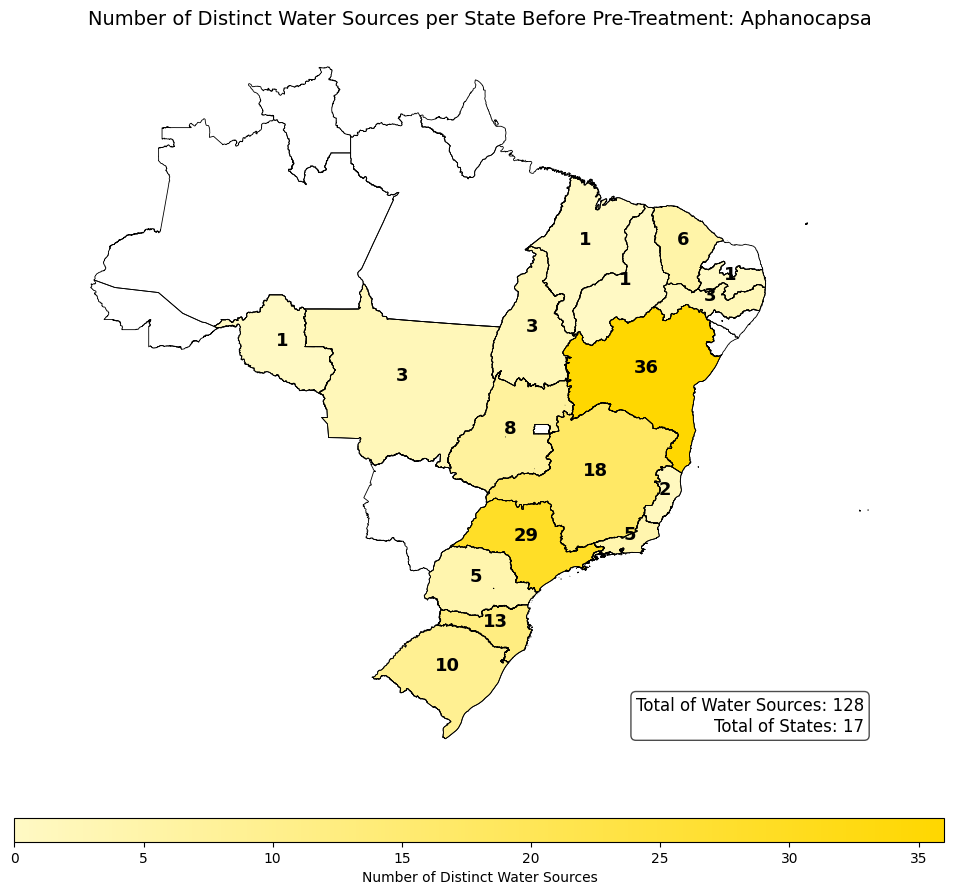

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Caminho para o shapefile
shapefile_path = "/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/Códigos atuais/BR_UF_2022.shx"

# Carregar o shapefile
brasil = gpd.read_file(shapefile_path)

# Criar um GeoDataFrame com a coluna 'UF' para garantir consistência
siglas_estados = [
    'AC', 'AM', 'PA', 'RR', 'TO', 'MA', 'PI', 'CE', 'RN', 'PB',
    'PE', 'AL', 'SE', 'BA', 'MG', 'ES', 'RJ', 'SP', 'PR', 'SC',
    'RS', 'MS', 'MT', 'GO', 'DF', 'RO', 'AP'
]
brasil['UF'] = siglas_estados
selecionadas_groupby = [df_aphanocapsa_final]
i = 0
# Loop para gerar mapas por bactéria
for df_conjunto_x in selecionadas_groupby:
    # Definir gradientes de cor alternados
    if i == 0:
        cmap = LinearSegmentedColormap.from_list("amarelo_pastel", ["#fff9c4", "#ffd700"])
    elif i == 1:
        cmap = LinearSegmentedColormap.from_list("roxo_pastel", ["#e6e6fa", "#9370db"])
    elif i == 2:
        cmap = LinearSegmentedColormap.from_list("verde_pastel", ["#d9f2d9", "#77dd77"])
    elif i == 3:
        cmap = LinearSegmentedColormap.from_list("pessego_pastel", ["#ffe5b4", "#ffdab9"])
    elif i == 4:
        cmap = LinearSegmentedColormap.from_list("azul_pastel", ["#E0FFFF", "#7FFFD4"])
    elif i == 5:
        cmap = LinearSegmentedColormap.from_list("vermelho_pastel", ["#f7c4c4", "#8b0000"])
    else:
        cmap = LinearSegmentedColormap.from_list("cinza_claro", ["#f2f2f2", "#d3d3d3"])

    # Contar mananciais distintos por UF
    mananciais_por_uf = df_conjunto_x.groupby('UF')['Nome_Rio_sisagua'].nunique().reset_index()
    mananciais_por_uf.columns = ['UF', 'Numero_Rios']

    # Juntar os dados ao GeoDataFrame do Brasil
    brasil_mapa = brasil.merge(mananciais_por_uf, on='UF', how='left')

    # Calcular o total de mananciais e UFs distintas
    total_mananciais = df_conjunto_x['Nome_Rio_sisagua'].nunique()
    total_ufs = df_conjunto_x['UF'].nunique()

    # Criar o mapa
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    brasil.boundary.plot(ax=ax, linewidth=0.6, edgecolor='black')  # Contornos
    brasil_mapa.plot(column='Numero_Rios', cmap=cmap, linewidth=0.6, ax=ax, edgecolor='black', legend=False)

    # Adicionar rótulos com os valores no centro dos estados
    for x, y, label in zip(brasil_mapa.geometry.centroid.x, brasil_mapa.geometry.centroid.y, brasil_mapa['Numero_Rios']):
        if not pd.isna(label):
            ax.text(x, y, str(int(label)), fontsize=13, ha='center', color='black', fontweight='bold')

    # Adicionar uma caixa de texto no canto inferior direito
    texto = f"Total of Water Sources: {total_mananciais}\nTotal of States: {total_ufs}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.7)
    ax.text(0.95, 0.05, texto, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

    # Legenda
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=brasil_mapa['Numero_Rios'].max()))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.05, aspect=40)
    cbar.set_label("Number of Distinct Water Sources", fontsize=10)

    # Título
    ax.axis('off')
    ax.set_title(f"Number of Distinct Water Sources per State Before Pre-Treatment: Aphanocapsa", fontsize=14)
    i += 1

    # Mostrar o gráfico
    plt.show()

In [ ]:
df_aphanocapsa_final['Classe_final'].value_counts()

,count
Classe_final,
0,2077
1,142


In [ ]:
df_aphanocapsa_final['Classe'] = df_aphanocapsa_final['Classe_final']
df_aphanocapsa_final.drop(columns=['Classe_final'], inplace=True)

In [ ]:
# ==============================================================================
# ANÁLISE DE DOMINÂNCIA DE APHANOCAPSA POR COMPOSIÇÃO DE GÊNEROS
# ==============================================================================

print("=== ANÁLISE DE DOMINÂNCIA DE APHANOCAPSA POR COMPOSIÇÃO ===\n")

# Análise por composição de gêneros
composition_analysis = df_aphanocapsa_final.groupby('Unidade_Conjunta').agg({
    'Classe': ['count', 'sum', 'mean'],
    'Total_Cianobacterias': ['mean', 'std', 'max'],
    'Aphanocapsa_Count': ['mean', 'std', 'max']
}).round(3)

# Renomear colunas para melhor legibilidade
composition_analysis.columns = ['Total_Amostras', 'Dominâncias_Count', 'Taxa_Dominância',
                               'Total_Ciano_Média', 'Total_Ciano_Std', 'Total_Ciano_Máx',
                               'Aphanocapsa_Média', 'Aphanocapsa_Std', 'Aphanocapsa_Máx']

print("📊 RESUMO POR COMPOSIÇÃO DE GÊNEROS:")
print(composition_analysis)

# Análise mais detalhada
print("\n🔍 ANÁLISE DETALHADA POR COMPOSIÇÃO:")

for genero_combo in df_aphanocapsa_final['Unidade_Conjunta'].unique():
    if pd.isna(genero_combo):
        continue

    subset = df_aphanocapsa_final[df_aphanocapsa_final['Unidade_Conjunta'] == genero_combo]

    total = len(subset)
    dominancias = subset['Classe'].sum()
    taxa = subset['Classe'].mean() * 100

    # Estatísticas de Aphanocapsa
    aphanocapsa_media = subset['Aphanocapsa_Count'].mean()
    aphanocapsa_max = subset['Aphanocapsa_Count'].max()

    # Estatísticas do total de cianobactérias
    total_ciano_media = subset['Total_Cianobacterias'].mean()
    total_ciano_max = subset['Total_Cianobacterias'].max()

    # Número de gêneros na composição
    num_generos = genero_combo.count(',') + 1

    print(f"\n🧬 {genero_combo}")
    print(f"  📊 Gêneros presentes: {num_generos}")
    print(f"  📈 Amostras: {total} ({total/len(df_aphanocapsa_final)*100:.1f}% do total)")
    print(f"  🎯 Dominâncias Aphanocapsa: {dominancias}/{total} ({taxa:.1f}%)")
    print(f"  🟢 Aphanocapsa média: {aphanocapsa_media:.0f} cél/mL")
    print(f"  🔴 Aphanocapsa máxima: {aphanocapsa_max:.0f} cél/mL")
    print(f"  🌊 Total ciano média: {total_ciano_media:.0f} cél/mL")
    print(f"  ⚠️  Total ciano máxima: {total_ciano_max:.0f} cél/mL")

# Análise por número de gêneros presentes
print("\n📊 ANÁLISE POR NÚMERO DE GÊNEROS PRESENTES:")
num_generos_analysis = df_aphanocapsa_final.groupby('Num_Generos').agg({
    'Classe': ['count', 'sum', 'mean'],
    'Aphanocapsa_Count': ['mean', 'max'],
    'Total_Cianobacterias': ['mean', 'max']
}).round(3)

num_generos_analysis.columns = ['Total_Amostras', 'Dominâncias', 'Taxa_Dominância',
                               'Aphanocapsa_Média', 'Aphanocapsa_Máx',
                               'Total_Média', 'Total_Máx']

print(num_generos_analysis)

# Teste estatístico - Chi-quadrado para independência
from scipy.stats import chi2_contingency

print(f"\n🧮 TESTE ESTATÍSTICO (Chi-quadrado):")
print("Testando se a composição de gêneros influencia a dominância de Aphanocapsa...")

# Criar tabela de contingência
contingency_table = pd.crosstab(df_aphanocapsa_final['Unidade_Conjunta'],
                               df_aphanocapsa_final['Classe'])
print("Tabela de contingência:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.6f}")
print(f"Graus de liberdade: {dof}")

if p_value < 0.05:
    print("✅ RESULTADO: Há diferença SIGNIFICATIVA na taxa de dominância entre composições!")
else:
    print("❌ RESULTADO: NÃO há diferença significativa na taxa de dominância entre composições")

# Ranking de "propensão à dominância"
print(f"\n🚨 RANKING DE PROPENSÃO À DOMINÂNCIA (maior → menor taxa):")
ranking = df_aphanocapsa_final.groupby('Unidade_Conjunta')['Classe'].mean().sort_values(ascending=False)

print("Top 10 composições mais propensas à dominância de Aphanocapsa:")
for i, (genero_combo, taxa) in enumerate(ranking.head(10).items(), 1):
    emoji = "🔴" if taxa > 0.8 else "🟡" if taxa > 0.5 else "🟢"
    num_generos = genero_combo.count(',') + 1 if pd.notna(genero_combo) else 0
    print(f"  {i}º {emoji} {genero_combo} ({num_generos} gêneros): {taxa*100:.1f}%")

# Análise de intensidade nas dominâncias (Classe 1)
print(f"\n💪 ANÁLISE DE INTENSIDADE NAS DOMINÂNCIAS (apenas Classe 1):")
dominancias_only = df_aphanocapsa_final[df_aphanocapsa_final['Classe'] == 1]

print("Composições com maiores intensidades de Aphanocapsa:")
intensidade_ranking = dominancias_only.groupby('Unidade_Conjunta')['Aphanocapsa_Count'].agg(['mean', 'median', 'max']).sort_values('mean', ascending=False)

for i, (genero_combo, stats) in enumerate(intensidade_ranking.head(5).iterrows(), 1):
    subset = dominancias_only[dominancias_only['Unidade_Conjunta'] == genero_combo]
    count = len(subset)

    print(f"\n{i}º {genero_combo} ({count} amostras):")
    print(f"  📊 Aphanocapsa média: {stats['mean']:.0f} cél/mL")
    print(f"  📊 Aphanocapsa mediana: {stats['median']:.0f} cél/mL")
    print(f"  📊 Aphanocapsa máxima: {stats['max']:.0f} cél/mL")

# Análise específica: Aphanocapsa sozinha vs com outros gêneros
print(f"\n🔬 ANÁLISE ESPECIAL: Aphanocapsa sozinha vs com outros gêneros")

aphanocapsa_sozinha = df_aphanocapsa_final[df_aphanocapsa_final['Num_Generos'] == 1]
aphanocapsa_com_outros = df_aphanocapsa_final[df_aphanocapsa_final['Num_Generos'] > 1]

print(f"\n📊 APHANOCAPSA SOZINHA:")
print(f"  Amostras: {len(aphanocapsa_sozinha)}")
print(f"  Taxa de dominância: {aphanocapsa_sozinha['Classe'].mean()*100:.1f}%")
print(f"  Aphanocapsa média: {aphanocapsa_sozinha['Aphanocapsa_Count'].mean():.0f} cél/mL")

print(f"\n📊 APHANOCAPSA COM OUTROS GÊNEROS:")
print(f"  Amostras: {len(aphanocapsa_com_outros)}")
print(f"  Taxa de dominância: {aphanocapsa_com_outros['Classe'].mean()*100:.1f}%")
print(f"  Aphanocapsa média: {aphanocapsa_com_outros['Aphanocapsa_Count'].mean():.0f} cél/mL")
print(f"  Gêneros médios por amostra: {aphanocapsa_com_outros['Num_Generos'].mean():.1f}")

# Conclusão
print(f"\n🎯 CONCLUSÕES PRINCIPAIS:")
total_amostras = len(df_aphanocapsa_final)
classe_1 = (df_aphanocapsa_final['Classe'] == 1).sum()
classe_0 = (df_aphanocapsa_final['Classe'] == 0).sum()

print(f"  📊 Total de amostras analisadas: {total_amostras}")
print(f"  🎯 Dominâncias de Aphanocapsa: {classe_1} ({classe_1/total_amostras*100:.1f}%)")
print(f"  🟢 Situações sem dominância: {classe_0} ({classe_0/total_amostras*100:.1f}%)")
print(f"  🧬 Composições diferentes encontradas: {df_aphanocapsa_final['Unidade_Conjunta'].nunique()}")
print(f"  📈 Diversidade média de gêneros: {df_aphanocapsa_final['Num_Generos'].mean():.1f} gêneros/amostra")

=== ANÁLISE DE DOMINÂNCIA DE APHANOCAPSA POR COMPOSIÇÃO ===

📊 RESUMO POR COMPOSIÇÃO DE GÊNEROS:
                                                    Total_Amostras  \
Unidade_Conjunta                                                     
Anabaena sp.                                                    75   
Anabaena sp., Aphanocapsa sp., Aphanothece sp.,...               1   
Anabaena sp., Aphanocapsa sp., Aphanothece sp.,...               2   
Anabaena sp., Aphanocapsa sp., Aphanothece sp.,...               1   
Anabaena sp., Aphanocapsa sp., Aphanothece sp.,...               1   
...                                                            ...   
Raphidiopsis sp., Synechococcus sp., Synechocys...               1   
Raphidiopsis sp., Synechocystis sp.                              1   
Sphaeropermopsis sp.                                             2   
Synechococcus sp.                                                4   
Synechocystis sp.                                              

In [ ]:
# 1. Converter de mbar para kPa
df_aphanocapsa_final['PRESSAO_KPA'] = df_aphanocapsa_final['PRESSAO_MEDIA_DIARIA'] / 10

# 2. Verificar a distribuição após conversão
print("=== APÓS CONVERSÃO PARA kPa ===")
print(df_aphanocapsa_final['PRESSAO_KPA'].describe())

# 3. Identificar valores problemáticos
print("\n=== VALORES PROBLEMÁTICOS ===")
problemas = df_aphanocapsa_final[
    (df_aphanocapsa_final['PRESSAO_KPA'] < 85) |
    (df_aphanocapsa_final['PRESSAO_KPA'] > 115)
]
print(f"Registros com pressão fora do normal: {len(problemas)} ({len(problemas)/len(df_aphanocapsa_final)*100:.1f}%)")

# 4. Ver quais são os valores problemáticos
print("\nValores únicos problemáticos:")
valores_prob = problemas['PRESSAO_KPA'].value_counts().head(20)
print(valores_prob)

# 5. Onde estão os problemas?
if len(problemas) > 0:
    print("\nEstados com valores problemáticos:")
    print(problemas.groupby('UF').size().sort_values(ascending=False))

# 6. Opções para tratar os dados:
print("\n=== OPÇÕES DE TRATAMENTO ===")

# Opção 2: Substituir por NaN
df_opcao2 = df_aphanocapsa_final.copy()
mask_invalida = (df_opcao2['PRESSAO_KPA'] < 75) | (df_opcao2['PRESSAO_KPA'] > 115)
df_opcao2.loc[mask_invalida, 'PRESSAO_KPA'] = np.nan
print(f"Opção 2 - NaN: {mask_invalida.sum()} valores substituídos por NaN")

# Aplicar correção recomendada
df_aphanocapsa_final['PRESSAO_KPA_CORRIGIDA'] = df_aphanocapsa_final['PRESSAO_KPA'].copy()
mask_invalida = (df_aphanocapsa_final['PRESSAO_KPA_CORRIGIDA'] < 75) | (df_aphanocapsa_final['PRESSAO_KPA_CORRIGIDA'] > 115)
df_aphanocapsa_final.loc[mask_invalida, 'PRESSAO_KPA_CORRIGIDA'] = np.nan

print(f"\n✅ Coluna 'PRESSAO_KPA_CORRIGIDA' criada!")
print(f"Valores válidos: {df_aphanocapsa_final['PRESSAO_KPA_CORRIGIDA'].notna().sum()}")
print(f"Valores NaN: {df_aphanocapsa_final['PRESSAO_KPA_CORRIGIDA'].isna().sum()}")

=== APÓS CONVERSÃO PARA kPa ===
count   2219.000
mean      93.023
std       15.154
min        0.000
25%       93.249
50%       96.266
75%       99.195
max      102.834
Name: PRESSAO_KPA, dtype: float64

=== VALORES PROBLEMÁTICOS ===
Registros com pressão fora do normal: 121 (5.5%)

Valores únicos problemáticos:
PRESSAO_KPA
37.060    9
4.195     4
54.352    3
64.323    3
4.258     3
4.101     3
53.397    3
29.575    2
38.285    2
25.255    2
4.244     2
16.872    2
37.943    2
40.256    2
64.090    2
44.258    2
41.155    2
33.116    2
0.000     2
12.800    2
Name: count, dtype: int64

Estados com valores problemáticos:
UF
SP    54
BA    35
CE    16
MG     5
TO     4
SC     2
RS     2
RJ     1
PE     1
PR     1
dtype: int64

=== OPÇÕES DE TRATAMENTO ===
Opção 2 - NaN: 121 valores substituídos por NaN

✅ Coluna 'PRESSAO_KPA_CORRIGIDA' criada!
Valores válidos: 2098
Valores NaN: 121


In [ ]:
df_aphanocapsa_final['Classe'].value_counts()

,count
Classe,
0,2077
1,142


In [ ]:
df_aphanocapsa_final.pivot_table(index='Diferenca_Dias_Num', columns='Classe', aggfunc='count')['UF'].reset_index()

Classe,Diferenca_Dias_Num,0,1
0,5.000,223.000,8.000
1,6.000,325.000,28.000
2,7.000,259.000,27.000
3,8.000,158.000,6.000
4,9.000,76.000,NaN
5,10.000,56.000,2.000
6,11.000,160.000,10.000
7,12.000,219.000,14.000
8,13.000,304.000,25.000
9,14.000,297.000,22.000


In [ ]:
df_aphanocapsa_final.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'Altitude',
       'station_id', 'data_inmet', 'fase', 'match_encontrado', 'Profundidade',
       'TempAr', 'TempAmostra', 'pH', 'Turbidez', 'CondutividadeEletrica',
       'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioTotal',
       'NitrogenioAmoniacal', 'Nitratos', 'FosforoTotal', 'Clorofila',
       'ODsaturacao', 'DescargaLiquida', 'OrtofosfatoTotal', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA'],
    

# Tirar linhas quase duplas (recoletas, classe 0 e 1)

In [ ]:
df_agg = df_aphanocapsa_final.copy()

In [ ]:
df_agg['Classe'].value_counts()

,count
Classe,
0,2077
1,142


In [ ]:
df_aphanocapsa_final = df_agg.copy()

In [ ]:
df_aphanocapsa_final = df_aphanocapsa_final.drop(['OrtofosfatoTotal'], axis=1)

In [ ]:
df_aphanocapsa_final.pivot_table(index='Diferenca_Dias_Num', columns='Classe', aggfunc='count')['UF'].reset_index()

Classe,Diferenca_Dias_Num,0,1
0,5.000,223.000,8.000
1,6.000,325.000,28.000
2,7.000,259.000,27.000
3,8.000,158.000,6.000
4,9.000,76.000,NaN
5,10.000,56.000,2.000
6,11.000,160.000,10.000
7,12.000,219.000,14.000
8,13.000,304.000,25.000
9,14.000,297.000,22.000


In [ ]:
df_aphanocapsa_final.head()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Região Geográfica,UF,Município,Código IBGE,Categoria do manancial superficial,Nome_Rio_sisagua,Estacao_Codigo_split,Nome_Municipio,Ano,Altitude,station_id,data_inmet,fase,match_encontrado,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,ODsaturacao,DescargaLiquida,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Unidade_Conjunta,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA
0,-23.396,-45.120,2020-01-15,2020-01-20,49860.000,SUDESTE,SP,SAO BERNARDO DO CAMPO,354870,represa,RIO GRANDE,21555000,UBATUBA,2020,70.000,498.000,2020-01-15,RAIO_60KM,True,NaN,26.000,22.000,7.300,5.000,NaN,25.000,3.000,7.400,50.000,NaN,50.000,NaN,NaN,0.320,0.020,2.670,NaN,NaN,59461.264,1180.975,0.000,202.208,1012.067,5.000,"Aphanocapsa sp., Cylindrospermopsis sp., Dolic...",6,42860.000,7000.000,1,101.207,101.207
1,-19.278,-44.006,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17357000,JEQUITIBA,2018,NaN,460.000,2018-09-04,RAIO_30KM,True,NaN,27.800,24.300,7.000,5.370,NaN,413.000,12.000,7.000,214.000,16.000,198.000,NaN,11.300,0.990,0.590,65.823,NaN,NaN,28032.579,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933
2,-19.021,-44.041,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17189000,CORDISBURGO,2018,NaN,460.000,2018-09-04,RAIO_60KM,True,NaN,29.000,25.100,8.000,15.700,NaN,357.000,21.000,10.300,234.000,22.000,212.000,NaN,2.530,1.520,0.360,308.004,NaN,NaN,53224.901,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933
3,-18.482,-44.198,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17209000,CURVELO,2018,NaN,337.000,2018-09-04,RAIO_60KM,True,NaN,30.500,25.800,8.400,22.900,NaN,226.000,5.400,10.600,158.000,18.000,140.000,NaN,0.220,1.270,0.130,114.810,NaN,NaN,43714.249,870.375,0.000,226.875,936.008,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.601,93.601
4,-18.312,-44.244,2018-09-05,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17605000,SANTO HIPOLITO,2018,NaN,337.000,2018-09-05,RAIO_60KM,True,NaN,19.500,23.300,7.600,29.300,NaN,222.000,4.700,7.800,194.000,40.000,154.000,NaN,0.120,1.430,0.140,133.500,NaN,NaN,58049.890,1014.846,0.000,210.167,939.738,13.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.974,93.974


In [ ]:
df_aphanocapsa_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219 entries, 0 to 2218
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            2219 non-null   float64       
 1   Longitude                           2219 non-null   float64       
 2   Date                                2219 non-null   datetime64[ns]
 3   Date_SISAGUA                        2219 non-null   datetime64[ns]
 4   Total_Cianobacterias                2219 non-null   float64       
 5   Região Geográfica                   2219 non-null   object        
 6   UF                                  2219 non-null   object        
 7   Município                           2219 non-null   object        
 8   Código IBGE                         2219 non-null   int64         
 9   Categoria do manancial superficial  2219 non-null   object        
 10  Nome_Rio_sisagua        

In [ ]:
# ESTAÇÕES DO ANO

# Converte a coluna Date_x para datetime
df_aphanocapsa_final['Date'] = pd.to_datetime(df_aphanocapsa_final['Date'])

# Tabela com as datas de início das estações do ano (hemisfério sul)
estacoes_inicio = {
    2014: {'Verao': '2013-12-21', 'Outono': '2014-03-20', 'Inverno': '2014-06-21', 'Primavera': '2014-09-23'},
    2015: {'Verao': '2014-12-21', 'Outono': '2015-03-20', 'Inverno': '2015-06-21', 'Primavera': '2015-09-23'},
    2016: {'Verao': '2015-12-22', 'Outono': '2016-03-20', 'Inverno': '2016-06-20', 'Primavera': '2016-09-22'},
    2017: {'Verao': '2016-12-21', 'Outono': '2017-03-20', 'Inverno': '2017-06-21', 'Primavera': '2017-09-22'},
    2018: {'Verao': '2017-12-21', 'Outono': '2018-03-20', 'Inverno': '2018-06-21', 'Primavera': '2018-09-22'},
    2019: {'Verao': '2018-12-21', 'Outono': '2019-03-20', 'Inverno': '2019-06-21', 'Primavera': '2019-09-23'},
    2020: {'Verao': '2019-12-22', 'Outono': '2020-03-20', 'Inverno': '2020-06-20', 'Primavera': '2020-09-22'},
    2021: {'Verao': '2020-12-21', 'Outono': '2021-03-20', 'Inverno': '2021-06-21', 'Primavera': '2021-09-22'},
    2022: {'Verao': '2021-12-21', 'Outono': '2022-03-20', 'Inverno': '2022-06-21', 'Primavera': '2022-09-23'},
    2023: {'Verao': '2022-12-21', 'Outono': '2023-03-20', 'Inverno': '2023-06-21', 'Primavera': '2023-09-23'}
}

# Função para determinar a estação do ano
def get_season(date):
    year = date.year
    start_dates = estacoes_inicio.get(year, None)
    if not start_dates:
        return None  # Se o ano não estiver na tabela, retorne None

    verao = pd.Timestamp(start_dates['Verao'])
    outono = pd.Timestamp(start_dates['Outono'])
    inverno = pd.Timestamp(start_dates['Inverno'])
    primavera = pd.Timestamp(start_dates['Primavera'])

    if verao <= date < outono:
        return 'Verao'
    elif outono <= date < inverno:
        return 'Outono'
    elif inverno <= date < primavera:
        return 'Inverno'
    else:
        return 'Primavera'

# Aplica a função para criar uma coluna com a estação
df_aphanocapsa_final['Estacao'] = df_aphanocapsa_final['Date'].apply(get_season)

# Cria colunas binárias para cada estação
df_aphanocapsa_final['Verao'] = (df_aphanocapsa_final['Estacao'] == 'Verao').astype(int)
df_aphanocapsa_final['Outono'] = (df_aphanocapsa_final['Estacao'] == 'Outono').astype(int)
df_aphanocapsa_final['Inverno'] = (df_aphanocapsa_final['Estacao'] == 'Inverno').astype(int)
df_aphanocapsa_final['Primavera'] = (df_aphanocapsa_final['Estacao'] == 'Primavera').astype(int)

# Remove a coluna intermediária de estação, se não for mais necessária
df_aphanocapsa_final.drop(columns=['Estacao'], inplace=True)

# Visualizar o resultado
df_aphanocapsa_final.head(5)

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Região Geográfica,UF,Município,Código IBGE,Categoria do manancial superficial,Nome_Rio_sisagua,Estacao_Codigo_split,Nome_Municipio,Ano,Altitude,station_id,data_inmet,fase,match_encontrado,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,ODsaturacao,DescargaLiquida,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Unidade_Conjunta,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera
0,-23.396,-45.120,2020-01-15,2020-01-20,49860.000,SUDESTE,SP,SAO BERNARDO DO CAMPO,354870,represa,RIO GRANDE,21555000,UBATUBA,2020,70.000,498.000,2020-01-15,RAIO_60KM,True,NaN,26.000,22.000,7.300,5.000,NaN,25.000,3.000,7.400,50.000,NaN,50.000,NaN,NaN,0.320,0.020,2.670,NaN,NaN,59461.264,1180.975,0.000,202.208,1012.067,5.000,"Aphanocapsa sp., Cylindrospermopsis sp., Dolic...",6,42860.000,7000.000,1,101.207,101.207,1,0,0,0
1,-19.278,-44.006,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17357000,JEQUITIBA,2018,NaN,460.000,2018-09-04,RAIO_30KM,True,NaN,27.800,24.300,7.000,5.370,NaN,413.000,12.000,7.000,214.000,16.000,198.000,NaN,11.300,0.990,0.590,65.823,NaN,NaN,28032.579,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933,0,0,1,0
2,-19.021,-44.041,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17189000,CORDISBURGO,2018,NaN,460.000,2018-09-04,RAIO_60KM,True,NaN,29.000,25.100,8.000,15.700,NaN,357.000,21.000,10.300,234.000,22.000,212.000,NaN,2.530,1.520,0.360,308.004,NaN,NaN,53224.901,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933,0,0,1,0
3,-18.482,-44.198,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17209000,CURVELO,2018,NaN,337.000,2018-09-04,RAIO_60KM,True,NaN,30.500,25.800,8.400,22.900,NaN,226.000,5.400,10.600,158.000,18.000,140.000,NaN,0.220,1.270,0.130,114.810,NaN,NaN,43714.249,870.375,0.000,226.875,936.008,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.601,93.601,0,0,1,0
4,-18.312,-44.244,2018-09-05,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17605000,SANTO HIPOLITO,2018,NaN,337.000,2018-09-05,RAIO_60KM,True,NaN,19.500,23.300,7.600,29.300,NaN,222.000,4.700,7.800,194.000,40.000,154.000,NaN,0.120,1.430,0.140,133.500,NaN,NaN,58049.890,1014.846,0.000,210.167,939.738,13.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.974,93.974,0,0,1,0


In [ ]:
# DELTA DE TEMPERATURA AR - TEMPERATURA AGUA (DELTA T)

df_aphanocapsa_final['Delta T'] = df_aphanocapsa_final['TempAr'] - df_aphanocapsa_final['TempAmostra']
df_aphanocapsa_final['Delta T'].head()

,Delta T
0,4.000
1,3.500
2,3.900
3,4.700
4,-3.800


In [ ]:
df_aphanocapsa_final.reset_index(drop=True, inplace=True)

In [ ]:
df_aphanocapsa_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219 entries, 0 to 2218
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            2219 non-null   float64       
 1   Longitude                           2219 non-null   float64       
 2   Date                                2219 non-null   datetime64[ns]
 3   Date_SISAGUA                        2219 non-null   datetime64[ns]
 4   Total_Cianobacterias                2219 non-null   float64       
 5   Região Geográfica                   2219 non-null   object        
 6   UF                                  2219 non-null   object        
 7   Município                           2219 non-null   object        
 8   Código IBGE                         2219 non-null   int64         
 9   Categoria do manancial superficial  2219 non-null   object        
 10  Nome_Rio_sisagua        

In [ ]:
df_aphanocapsa_final['N:P'] = df_aphanocapsa_final['NitrogenioTotal']/df_aphanocapsa_final['FosforoTotal']

In [ ]:
df_aphanocapsa_final['%SolDissolvidos'] =  df_aphanocapsa_final['SolDissolvidosTotais']/df_aphanocapsa_final['SolTotais']
df_aphanocapsa_final['%SolSuspensao'] =  df_aphanocapsa_final['SolSuspensaoTotais']/df_aphanocapsa_final['SolTotais']

In [ ]:
df_aphanocapsa_final.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'Altitude',
       'station_id', 'data_inmet', 'fase', 'match_encontrado', 'Profundidade',
       'TempAr', 'TempAmostra', 'pH', 'Turbidez', 'CondutividadeEletrica',
       'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioTotal',
       'NitrogenioAmoniacal', 'Nitratos', 'FosforoTotal', 'Clorofila',
       'ODsaturacao', 'DescargaLiquida', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inver

In [ ]:
df_aphanocapsa_final_c1 = df_aphanocapsa_final[df_aphanocapsa_final['Classe']==1]
df_aphanocapsa_final_c0 = df_aphanocapsa_final[df_aphanocapsa_final['Classe']==0]

In [ ]:
df_aphanocapsa_final_c1.describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,Altitude,station_id,data_inmet,Profundidade,TempAr,TempAmostra,pH,Turbidez,CondutividadeEletrica,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioTotal,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,ODsaturacao,DescargaLiquida,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,N:P,%SolDissolvidos,%SolSuspensao
count,142.000,142.000,142,142,142.000,142.000,142.000,142.000,42.000,142.000,142,46.000,133.000,133.000,133.000,120.000,27.000,106.000,101.000,128.000,67.000,82.000,110.000,45.000,87.000,88.000,101.000,102.000,17.000,24.000,142.000,142.000,142.000,142.000,142.000,142.000,142.000,142.000,142.000,142.000,142.000,139.000,142.000,142.000,142.000,142.000,133.000,44.000,67.000,40.000
mean,-7.750,-39.471,2018-06-30 12:00:00,2018-07-10 04:33:48.169014016,134636.831,249045.901,10923766.197,2017.972,237.822,191.894,2018-06-30 12:00:00,0.250,26.983,28.314,8.454,12.826,7676.933,1703.478,6.110,7.728,1391.946,748.533,2102.542,2.336,0.586,0.479,0.317,29.932,87.882,0.968,28747.607,834.931,1.585,130.561,972.064,9.690,1.930,125637.563,8999.268,1.000,97.206,98.158,0.148,0.352,0.317,0.183,-1.331,35.953,0.941,0.214
min,-23.396,-49.244,2016-09-22 00:00:00,2016-10-04 00:00:00,20400.000,230150.000,9004000.000,2016.000,4.000,51.000,2016-09-22 00:00:00,0.000,0.000,0.000,0.000,0.000,122.400,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.000,0.000,0.007,0.000,43.100,0.000,860.624,277.196,0.000,14.250,379.433,5.000,1.000,10619.000,0.000,1.000,37.943,85.383,0.000,0.000,0.000,0.000,-30.150,1.689,0.276,0.000
25%,-7.082,-40.084,2017-12-12 00:00:00,2017-12-26 00:00:00,31833.000,230150.000,9055000.000,2017.000,82.500,73.000,2017-12-12 00:00:00,0.200,26.400,26.900,7.300,3.067,354.000,312.950,3.000,5.660,184.500,5.150,190.750,1.000,0.200,0.100,0.100,2.100,65.100,0.009,15307.520,733.009,0.000,95.167,965.151,6.250,1.000,25025.000,0.000,1.000,96.515,96.569,0.000,0.000,0.000,0.000,-1.500,13.043,0.936,0.029
50%,-6.237,-38.913,2018-06-12 00:00:00,2018-06-21 00:00:00,53233.000,230150.000,9095000.000,2018.000,211.000,98.000,2018-06-12 00:00:00,0.300,29.100,28.800,8.000,6.650,508.700,465.000,4.000,7.750,261.200,14.200,279.000,1.238,0.310,0.300,0.200,4.300,75.400,0.277,31044.750,856.419,0.000,125.375,992.625,10.500,2.000,43376.000,4945.000,1.000,99.263,99.263,0.000,0.000,0.000,0.000,-0.400,25.373,0.970,0.103
75%,-5.228,-38.198,2018-09-05 00:00:00,2018-09-17 18:00:00,120872.250,230533.000,9133000.000,2018.000,401.000,130.000,2018-09-05 00:00:00,0.300,31.000,30.500,8.570,10.075,642.550,650.000,7.100,9.500,364.500,49.250,424.000,2.337,0.400,0.710,0.500,29.625,90.100,1.325,41422.354,969.103,0.000,149.469,1008.946,13.000,2.000,116396.750,12698.000,1.000,100.895,100.904,0.000,1.000,1.000,0.000,2.100,50.000,0.987,0.218
max,-4.317,-35.173,2022-08-17 00:00:00,2022-08-27 00:00:00,1686877.000,520870.000,26088000.000,2022.000,610.000,1247.000,2022-08-17 00:00:00,0.300,39.900,34.600,83.400,131.000,73400.000,60200.000,39.000,20.300,40753.000,59400.000,40740.000,21.300,11.300,3.500,1.500,327.000,289.000,3.829,59461.264,1191.554,54.200,360.000,1018.550,14.000,7.000,1684671.000,44940.000,1.000,101.855,101.855,1.000,1.000,1.000,1.000,9.900,367.241,1.017,1.000
std,4.114,2.025,NaN,NaN,231981.147,43601.071,3603464.672,0.982,164.832,230.694,NaN,0.089,8.506,3.697,6.630,19.385,20609.179,7231.365,6.207,3.140,6220.214,6556.978,7470.703,3.261,1.282,0.599,0.307,59.670,55.111,1.270,16143.341,186.655,6.950,62.732,76.975,3.310,1.076,233568.574,11237.548,0.000,7.698,3.572,0.356,0.479,0.467,0.388,7.802,53.983,0.100,0.286


In [ ]:
# Calculando a porcentagem de valores nulos em cada coluna
null_percentage = (df_aphanocapsa_final_c1.isnull().sum() / len(df_aphanocapsa_final_c1)) * 100

# Criando o dataframe com duas colunas: Feature e Porcentagem
df_aphanocapsa_final_c1_perc = pd.DataFrame({
    "Feature": df_aphanocapsa_final_c1.columns,
    "Porcentagem (%)": null_percentage
}).reset_index(drop=True)

# Formatando a coluna de porcentagem com duas casas decimais
#df_micro_c1_perc["Porcentagem (%)"] = df_micro_c1_perc["Porcentagem (%)"].map("{:.2f}".format)

# Exibindo o dataframe gerado
df_aphanocapsa_final_c1_perc.sort_values(by="Porcentagem (%)", ascending=False)

,Feature,Porcentagem (%)
36,ODsaturacao,88.028
37,DescargaLiquida,83.099
24,CondutividadeEletrica,80.986
58,%SolSuspensao,71.831
14,Altitude,70.423
56,N:P,69.014
31,NitrogenioTotal,68.310
19,Profundidade,67.606
57,%SolDissolvidos,52.817
28,SolTotais,52.817


In [ ]:
# Calculando a porcentagem de valores nulos em cada coluna
null_percentage = (df_aphanocapsa_final_c0.isnull().sum() / len(df_aphanocapsa_final_c0)) * 100

# Criando o dataframe com duas colunas: Feature e Porcentagem
df_aphanocapsa_final_c0_perc = pd.DataFrame({
    "Feature": df_aphanocapsa_final_c0.columns,
    "Porcentagem (%)": null_percentage
}).reset_index(drop=True)

# Formatando a coluna de porcentagem com duas casas decimais
#df_micro_c1_perc["Porcentagem (%)"] = df_micro_c1_perc["Porcentagem (%)"].map("{:.2f}".format)

# Exibindo o dataframe gerado
df_aphanocapsa_final_c0_perc.sort_values(by="Porcentagem (%)", ascending=False)

,Feature,Porcentagem (%)
37,DescargaLiquida,90.467
24,CondutividadeEletrica,83.052
36,ODsaturacao,75.060
58,%SolSuspensao,70.679
19,Profundidade,70.053
56,N:P,67.501
31,NitrogenioTotal,66.394
57,%SolDissolvidos,55.079
28,SolTotais,54.309
29,SolSuspensaoTotais,49.398


In [ ]:
df_aphanocapsa_final.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'Altitude',
       'station_id', 'data_inmet', 'fase', 'match_encontrado', 'Profundidade',
       'TempAr', 'TempAmostra', 'pH', 'Turbidez', 'CondutividadeEletrica',
       'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioTotal',
       'NitrogenioAmoniacal', 'Nitratos', 'FosforoTotal', 'Clorofila',
       'ODsaturacao', 'DescargaLiquida', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inver

# TESTE

In [ ]:
import pandas as pd

# Ensure the percentage column is numeric
df_aphanocapsa_final_c1_perc['Porcentagem (%)'] = pd.to_numeric(df_aphanocapsa_final_c1_perc['Porcentagem (%)'])
df_aphanocapsa_final_c0_perc['Porcentagem (%)'] = pd.to_numeric(df_aphanocapsa_final_c0_perc['Porcentagem (%)'])

# ==============================================================================
# 2. Merge the DataFrames
# ==============================================================================
# Merge based on the 'Feature' column
merged_df = pd.merge(
    df_aphanocapsa_final_c1_perc,
    df_aphanocapsa_final_c0_perc,
    on='Feature',
    suffixes=('_C1', '_C0'), # Add suffixes to distinguish percentage columns
    how='inner' # Use 'inner' to only keep features present in both DFs
)

# Rename columns for clarity
merged_df.rename(columns={
    'Porcentagem (%)_C1': 'Perc_Null_C1',
    'Porcentagem (%)_C0': 'Perc_Null_C0'
}, inplace=True)

cond2 = (merged_df['Perc_Null_C0'] <= 60) & (merged_df['Perc_Null_C1'] <= 60)

# Combine all conditions with OR (|)
# A feature is kept if ANY of the conditions are true
keep_mask = cond2

# ==============================================================================
# 4. Get the Lists of Features
# ==============================================================================

# DataFrame of features to keep
features_to_keep_df = merged_df[keep_mask].copy() # Use .copy() to avoid SettingWithCopyWarning

# List of feature names to keep
features_to_keep_list = features_to_keep_df['Feature'].tolist()

# DataFrame of features to drop (for review)
features_to_drop_df = merged_df[~keep_mask].copy() # Use ~ to negate the mask

# List of feature names to drop
features_to_drop_list = features_to_drop_df['Feature'].tolist()

print(f"\n>>> {len(features_to_keep_list)} Features to KEEP:")
# Sort alphabetically for easier reading
features_to_keep_list.sort()
print(features_to_keep_list)

print(f"\n>>> {len(features_to_drop_list)} Features to DROP:")
# Sort alphabetically for easier reading
features_to_drop_list.sort()
print(features_to_drop_list)
print("-" * 50)


>>> 51 Features to KEEP:
['%SolDissolvidos', 'Ano', 'Aphanocapsa_Count', 'Categoria do manancial superficial', 'Classe', 'Clorofila', 'CondutividadeEspecifica', 'Código IBGE', 'DBO', 'Date', 'Date_SISAGUA', 'Delta T', 'Diferenca_Dias_Num', 'Estacao_Codigo_split', 'FosforoTotal', 'Inverno', 'Latitude', 'Longitude', 'Município', 'Nitratos', 'NitrogenioAmoniacal', 'Nome_Municipio', 'Nome_Rio_sisagua', 'Num_Generos', 'OD', 'Outono', 'Outras_Cianobacterias', 'PRECIPITACAO_SOMA_DIARIA', 'PRESSAO_KPA', 'PRESSAO_KPA_CORRIGIDA', 'PRESSAO_MEDIA_DIARIA', 'Primavera', 'RADIACAO_MEDIA_DIARIA', 'Região Geográfica', 'SolDissolvidosTotais', 'SolSuspensaoTotais', 'SolTotais', 'TempAmostra', 'TempAr', 'Total_Cianobacterias', 'Turbidez', 'UF', 'Unidade_Conjunta', 'VENTO_MEDIA_DIARIA', 'Verao', 'data_inmet', 'distancia_m', 'fase', 'match_encontrado', 'pH', 'station_id']

>>> 8 Features to DROP:
['%SolSuspensao', 'Altitude', 'CondutividadeEletrica', 'DescargaLiquida', 'N:P', 'NitrogenioTotal', 'ODsaturaca

In [ ]:
features_to_keep_df.sort_values(by=['Perc_Null_C1', 'Perc_Null_C0'], ascending=False).reset_index(drop=True)

,Feature,Perc_Null_C1,Perc_Null_C0
0,%SolDissolvidos,52.817,55.079
1,SolTotais,52.817,54.309
2,SolSuspensaoTotais,42.254,49.398
3,NitrogenioAmoniacal,38.732,43.139
4,Nitratos,38.028,49.109
5,FosforoTotal,28.873,38.325
6,DBO,28.873,27.732
7,Clorofila,28.169,41.358
8,CondutividadeEspecifica,25.352,40.636
9,SolDissolvidosTotais,22.535,32.258


# fim do teste

In [ ]:
df_aphanocapsa_final_50 = df_aphanocapsa_final[features_to_keep_df['Feature']]
df_aphanocapsa_final_50.head(5)

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Região Geográfica,UF,Município,Código IBGE,Categoria do manancial superficial,Nome_Rio_sisagua,Estacao_Codigo_split,Nome_Municipio,Ano,station_id,data_inmet,fase,match_encontrado,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Unidade_Conjunta,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
0,-23.396,-45.120,2020-01-15,2020-01-20,49860.000,SUDESTE,SP,SAO BERNARDO DO CAMPO,354870,represa,RIO GRANDE,21555000,UBATUBA,2020,498.000,2020-01-15,RAIO_60KM,True,26.000,22.000,7.300,5.000,25.000,3.000,7.400,50.000,NaN,50.000,NaN,0.320,0.020,2.670,59461.264,1180.975,0.000,202.208,1012.067,5.000,"Aphanocapsa sp., Cylindrospermopsis sp., Dolic...",6,42860.000,7000.000,1,101.207,101.207,1,0,0,0,4.000,1.000
1,-19.278,-44.006,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17357000,JEQUITIBA,2018,460.000,2018-09-04,RAIO_30KM,True,27.800,24.300,7.000,5.370,413.000,12.000,7.000,214.000,16.000,198.000,11.300,0.990,0.590,65.823,28032.579,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933,0,0,1,0,3.500,0.925
2,-19.021,-44.041,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17189000,CORDISBURGO,2018,460.000,2018-09-04,RAIO_60KM,True,29.000,25.100,8.000,15.700,357.000,21.000,10.300,234.000,22.000,212.000,2.530,1.520,0.360,308.004,53224.901,834.425,0.000,231.917,929.329,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,92.933,92.933,0,0,1,0,3.900,0.906
3,-18.482,-44.198,2018-09-04,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17209000,CURVELO,2018,337.000,2018-09-04,RAIO_60KM,True,30.500,25.800,8.400,22.900,226.000,5.400,10.600,158.000,18.000,140.000,0.220,1.270,0.130,114.810,43714.249,870.375,0.000,226.875,936.008,14.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.601,93.601,0,0,1,0,4.700,0.886
4,-18.312,-44.244,2018-09-05,2018-09-18,23676.000,SUDESTE,MG,VARZEA DA PALMA,317080,rio,RIO DAS VELHAS,17605000,SANTO HIPOLITO,2018,337.000,2018-09-05,RAIO_60KM,True,19.500,23.300,7.600,29.300,222.000,4.700,7.800,194.000,40.000,154.000,0.120,1.430,0.140,133.500,58049.890,1014.846,0.000,210.167,939.738,13.000,Aphanocapsa sp.,1,23676.000,0.000,1,93.974,93.974,0,0,1,0,-3.800,0.794


In [ ]:
df_aphanocapsa_final_50.describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,station_id,data_inmet,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
count,2219.000,2219.000,2219,2219,2219.000,2219.000,2219.000,2219.000,2219.000,2219,1679.000,2011.000,2005.000,1908.000,1339.000,1602.000,1962.000,1016.000,1133.000,1517.000,1268.000,1145.000,1382.000,1320.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2219.000,2098.000,2219.000,2219.000,2219.000,2219.000,1675.000,1000.000
mean,-17.847,-45.056,2019-01-24 09:31:43.019378176,2019-02-02 23:28:12.113564672,11837.543,324501.585,18612610.545,2018.563,527.758,2019-01-24 09:31:43.019378176,27.156,25.139,7.333,28.590,595.516,5.813,7.336,374.949,272.928,485.777,1.460,0.560,0.215,12.673,33056.429,744.889,3.572,142.031,930.225,9.581,2.003,8847.332,2990.211,0.064,93.023,96.390,0.244,0.216,0.229,0.311,1.855,0.862
min,-31.574,-63.240,2015-04-15 00:00:00,2015-04-23 00:00:00,1.000,110002.000,1001000.000,2015.000,23.000,2015-04-15 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,354.116,0.067,0.000,0.000,0.000,5.000,1.000,0.000,0.000,0.000,0.000,85.383,0.000,0.000,0.000,0.000,-30.150,0.055
25%,-23.194,-48.690,2017-11-22 00:00:00,2017-12-04 00:00:00,168.000,290820.000,16164000.000,2017.000,239.000,2017-11-22 00:00:00,25.000,22.900,6.860,3.700,64.900,2.000,5.600,77.750,43.200,60.000,0.169,0.030,0.020,1.090,21258.765,578.042,0.000,102.375,932.485,6.000,1.000,0.000,64.500,0.000,93.249,93.938,0.000,0.000,0.000,0.000,-0.300,0.804
50%,-20.669,-46.416,2018-09-12 00:00:00,2018-09-26 00:00:00,1650.000,350570.000,21077000.000,2018.000,421.000,2018-09-12 00:00:00,28.000,25.600,7.250,9.400,116.000,3.000,6.900,118.000,50.000,100.000,0.400,0.200,0.050,2.100,34506.157,758.092,0.000,141.042,962.658,9.000,2.000,0.000,631.000,0.000,96.266,96.405,0.000,0.000,0.000,0.000,2.000,0.910
75%,-12.603,-40.349,2019-12-03 00:00:00,2019-12-10 00:00:00,6400.000,354500.000,21416000.000,2019.000,909.000,2019-12-03 00:00:00,30.500,27.930,7.810,24.000,302.000,4.000,8.000,228.000,100.000,194.000,0.500,0.560,0.180,9.252,45187.195,949.421,1.000,185.729,991.954,13.000,2.000,518.500,4000.000,0.000,99.195,99.443,0.000,0.000,0.000,1.000,4.400,0.983
max,-3.054,-34.959,2022-12-05 00:00:00,2022-12-19 00:00:00,1686877.000,521940.000,29121000.000,2022.000,1263.000,2022-12-05 00:00:00,41.300,36.300,83.400,2765.000,69888.000,485.000,290.000,59058.000,100000.000,47342.000,30.100,17.100,15.000,513.220,59986.211,1852.487,78.200,360.000,1028.342,14.000,18.000,1684671.000,44940.000,1.000,102.834,102.834,1.000,1.000,1.000,1.000,14.200,1.154
std,7.096,4.593,NaN,NaN,66884.369,63628.508,4820230.648,1.530,348.139,NaN,5.630,4.122,1.999,86.349,4274.149,15.944,12.404,2527.045,3875.347,3242.100,3.932,1.270,0.623,34.953,15461.043,276.615,9.636,66.097,151.537,3.255,1.536,66382.796,5105.860,0.245,15.154,3.599,0.429,0.412,0.421,0.463,4.486,0.161


In [ ]:
df_aphanocapsa_final_50.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'station_id',
       'data_inmet', 'fase', 'match_encontrado', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioAmoniacal',
       'Nitratos', 'FosforoTotal', 'Clorofila', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inverno', 'Primavera',
       'Delta T', '%SolDissolvidos'],
      dtype='object')

In [ ]:
#df_aphanocapsa_final_50 = df_aphanocapsa_final_50.drop([], axis=1).reset_index(drop=True)
df_aphanocapsa_final_50.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219 entries, 0 to 2218
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            2219 non-null   float64       
 1   Longitude                           2219 non-null   float64       
 2   Date                                2219 non-null   datetime64[ns]
 3   Date_SISAGUA                        2219 non-null   datetime64[ns]
 4   Total_Cianobacterias                2219 non-null   float64       
 5   Região Geográfica                   2219 non-null   object        
 6   UF                                  2219 non-null   object        
 7   Município                           2219 non-null   object        
 8   Código IBGE                         2219 non-null   int64         
 9   Categoria do manancial superficial  2219 non-null   object        
 10  Nome_Rio_sisagua        

In [ ]:
def remove_rows_with_high_null_percentage_by_class(df, threshold_class_0=0.05, threshold_class_1=0.08, class_column='Classe'):
    """
    Remove linhas com limiares diferentes para cada classe:
    - Classe 0: remove linhas com >= threshold_class_0 de valores nulos
    - Classe 1: remove linhas com >= threshold_class_1 de valores nulos

    Parameters:
    df (pandas.DataFrame): DataFrame original
    threshold_class_0 (float): Porcentagem limite para classe 0 (0.10 = 10%)
    threshold_class_1 (float): Porcentagem limite para classe 1 (0.10 = 10%)
    class_column (str): Nome da coluna de classe

    Returns:
    pandas.DataFrame: DataFrame filtrado
    dict: Informações sobre a remoção
    """

    # Informações do dataframe original
    original_shape = df.shape
    total_columns = df.shape[1]

    # Separar dados por classe
    df_class_0 = df[df[class_column] == 0].copy()
    df_class_1 = df[df[class_column] == 1].copy()

    # Informações originais por classe
    original_class_0_count = len(df_class_0)
    original_class_1_count = len(df_class_1)

    # Aplicar filtro na classe 0
    if len(df_class_0) > 0:
        # Calcular o número de valores nulos por linha na classe 0
        null_counts_per_row_class_0 = df_class_0.isnull().sum(axis=1)
        null_percentage_per_row_class_0 = null_counts_per_row_class_0 / total_columns

        # Identificar linhas da classe 0 que devem ser mantidas
        rows_to_keep_class_0 = null_percentage_per_row_class_0 < threshold_class_0
        df_class_0_filtered = df_class_0[rows_to_keep_class_0].copy()
    else:
        df_class_0_filtered = df_class_0.copy()

    # Aplicar filtro na classe 1
    if len(df_class_1) > 0:
        # Calcular o número de valores nulos por linha na classe 1
        null_counts_per_row_class_1 = df_class_1.isnull().sum(axis=1)
        null_percentage_per_row_class_1 = null_counts_per_row_class_1 / total_columns

        # Identificar linhas da classe 1 que devem ser mantidas
        rows_to_keep_class_1 = null_percentage_per_row_class_1 < threshold_class_1
        df_class_1_filtered = df_class_1[rows_to_keep_class_1].copy()
    else:
        df_class_1_filtered = df_class_1.copy()

    # Combinar ambas as classes filtradas
    df_filtered = pd.concat([df_class_0_filtered, df_class_1_filtered], ignore_index=True)

    # Informações sobre a remoção
    filtered_class_0_count = len(df_class_0_filtered)
    filtered_class_1_count = len(df_class_1_filtered)
    removed_class_0_rows = original_class_0_count - filtered_class_0_count
    removed_class_1_rows = original_class_1_count - filtered_class_1_count
    total_removed_rows = removed_class_0_rows + removed_class_1_rows

    info = {
        'original_total_rows': original_shape[0],
        'original_class_0_rows': original_class_0_count,
        'original_class_1_rows': original_class_1_count,
        'filtered_total_rows': len(df_filtered),
        'filtered_class_0_rows': filtered_class_0_count,
        'filtered_class_1_rows': filtered_class_1_count,
        'removed_class_0_rows': removed_class_0_rows,
        'removed_class_1_rows': removed_class_1_rows,
        'total_removed_rows': total_removed_rows,
        'removal_percentage_class_0': (removed_class_0_rows / original_class_0_count * 100) if original_class_0_count > 0 else 0,
        'removal_percentage_class_1': (removed_class_1_rows / original_class_1_count * 100) if original_class_1_count > 0 else 0,
        'removal_percentage_total': (total_removed_rows / original_shape[0]) * 100,
        'threshold_class_0': threshold_class_0 * 100,
        'threshold_class_1': threshold_class_1 * 100
    }

    return df_filtered, info

# Aplicar a função com limiares diferentes por classe: 5% para classe 0, 5% para classe 1
df_aphanocapsa_final_filtered, removal_info = remove_rows_with_high_null_percentage_by_class(
    df_aphanocapsa_final_50,
    threshold_class_0=0.02,  # 10% para classe 0
    threshold_class_1=0.20,   # 10% para classe 1
)

# Exibir informações sobre a remoção
print("=" * 70)
print("RELATÓRIO DE REMOÇÃO DE LINHAS (LIMIARES DIFERENTES POR CLASSE)")
print("=" * 70)
print(f"Linhas originais (total): {removal_info['original_total_rows']:,}")
print(f"  • Classe 0: {removal_info['original_class_0_rows']:,}")
print(f"  • Classe 1: {removal_info['original_class_1_rows']:,}")
print()
print(f"Linhas após filtro (total): {removal_info['filtered_total_rows']:,}")
print(f"  • Classe 0: {removal_info['filtered_class_0_rows']:,}")
print(f"  • Classe 1: {removal_info['filtered_class_1_rows']:,}")
print()
print(f"Linhas removidas:")
print(f"  • Classe 0: {removal_info['removed_class_0_rows']:,} ({removal_info['removal_percentage_class_0']:.2f}%)")
print(f"  • Classe 1: {removal_info['removed_class_1_rows']:,} ({removal_info['removal_percentage_class_1']:.2f}%)")
print(f"  • Total: {removal_info['total_removed_rows']:,} ({removal_info['removal_percentage_total']:.2f}%)")
print()
print(f"Critérios usados:")
print(f"  • Classe 0: >= {removal_info['threshold_class_0']:.0f}% de valores nulos")
print(f"  • Classe 1: >= {removal_info['threshold_class_1']:.0f}% de valores nulos")
print("=" * 70)

# Verificar a nova estrutura do dataframe
print("\nINFORMAÇÕES DO DATAFRAME FILTRADO:")
print(df_aphanocapsa_final_filtered.info())

# Opcional: Salvar o dataframe filtrado
# df_aphanocapsa_final_filtered.to_csv('df_aphanocapsa_final_filtered.csv', index=False)

# Verificação adicional: Distribuição de classes antes e depois
print("\nDISTRIBUIÇÃO DE CLASSES:")
print("Antes do filtro:")
print(df_aphanocapsa_final_50['Classe'].value_counts().sort_index())
print("\nDepois do filtro:")
print(df_aphanocapsa_final_filtered['Classe'].value_counts().sort_index())

# Verificação adicional: mostrar estatísticas de valores nulos por coluna no dataframe filtrado
print("\nVALORES NULOS POR COLUNA (APÓS FILTRO):")
null_summary = df_aphanocapsa_final_filtered.isnull().sum()
null_summary_filtered = null_summary[null_summary > 0].sort_values(ascending=False)
print(null_summary_filtered)

RELATÓRIO DE REMOÇÃO DE LINHAS (LIMIARES DIFERENTES POR CLASSE)
Linhas originais (total): 2,219
  • Classe 0: 2,077
  • Classe 1: 142

Linhas após filtro (total): 694
  • Classe 0: 566
  • Classe 1: 128

Linhas removidas:
  • Classe 0: 1,511 (72.75%)
  • Classe 1: 14 (9.86%)
  • Total: 1,525 (68.72%)

Critérios usados:
  • Classe 0: >= 2% de valores nulos
  • Classe 1: >= 20% de valores nulos

INFORMAÇÕES DO DATAFRAME FILTRADO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            694 non-null    float64       
 1   Longitude                           694 non-null    float64       
 2   Date                                694 non-null    datetime64[ns]
 3   Date_SISAGUA                        694 non-null    datetime64[ns]
 4   Total_Cianobacterias      

In [ ]:
df_aphanocapsa_final_filtered['Classe'].value_counts()

,count
Classe,
0,566
1,128


In [ ]:
df_aphanocapsa_final_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            694 non-null    float64       
 1   Longitude                           694 non-null    float64       
 2   Date                                694 non-null    datetime64[ns]
 3   Date_SISAGUA                        694 non-null    datetime64[ns]
 4   Total_Cianobacterias                694 non-null    float64       
 5   Região Geográfica                   694 non-null    object        
 6   UF                                  694 non-null    object        
 7   Município                           694 non-null    object        
 8   Código IBGE                         694 non-null    int64         
 9   Categoria do manancial superficial  694 non-null    object        
 10  Nome_Rio_sisagua          

### Verificação Null Colunas + VERIFICAÇÃO POR CLASSE

In [ ]:
# Calculando a porcentagem de valores nulos em cada coluna
null_percentage = (df_aphanocapsa_final_filtered.isnull().sum() / len(df_aphanocapsa_final_filtered)) * 100

# Criando o dataframe com duas colunas: Feature e Porcentagem
df_aphanocapsa_final_perc_filtered = pd.DataFrame({
    "Feature": df_aphanocapsa_final_filtered.columns,
    "Porcentagem (%)": null_percentage
}).reset_index(drop=True)

# Exibindo o dataframe gerado
df_aphanocapsa_final_perc_filtered.sort_values(by="Porcentagem (%)", ascending=False)

,Feature,Porcentagem (%)
22,CondutividadeEspecifica,17.147
26,SolSuspensaoTotais,15.418
25,SolTotais,8.790
50,%SolDissolvidos,8.790
28,NitrogenioAmoniacal,6.916
29,Nitratos,5.764
31,Clorofila,4.467
23,DBO,4.323
44,PRESSAO_KPA_CORRIGIDA,4.035
30,FosforoTotal,3.890


In [ ]:
df_aphanocapsa_final_filtered_1 = df_aphanocapsa_final_filtered[df_aphanocapsa_final_filtered['Classe']==1]
df_aphanocapsa_final_filtered_0 = df_aphanocapsa_final_filtered[df_aphanocapsa_final_filtered['Classe']==0]

In [ ]:
# Calculando a porcentagem de valores nulos em cada coluna
null_percentage_1 = (df_aphanocapsa_final_filtered_1.isnull().sum() / len(df_aphanocapsa_final_filtered_1)) * 100

# Criando o dataframe com duas colunas: Feature e Porcentagem
df_aphanocapsa_final_perc_filtered_classe1 = pd.DataFrame({
    "Feature": df_aphanocapsa_final_filtered_1.columns,
    "Porcentagem (%)": null_percentage_1
}).reset_index(drop=True)

# Exibindo o dataframe gerado
df_aphanocapsa_final_perc_filtered_classe1.sort_values(by="Porcentagem (%)", ascending=False)

,Feature,Porcentagem (%)
25,SolTotais,47.656
50,%SolDissolvidos,47.656
26,SolSuspensaoTotais,35.938
28,NitrogenioAmoniacal,32.031
29,Nitratos,31.250
23,DBO,21.094
30,FosforoTotal,21.094
31,Clorofila,20.312
22,CondutividadeEspecifica,19.531
27,SolDissolvidosTotais,14.062


In [ ]:
# Calculando a porcentagem de valores nulos em cada coluna
null_percentage_0 = (df_aphanocapsa_final_filtered_0.isnull().sum() / len(df_aphanocapsa_final_filtered_0)) * 100

# Criando o dataframe com duas colunas: Feature e Porcentagem
df_aphanocapsa_final_perc_filtered_classe0 = pd.DataFrame({
    "Feature": df_aphanocapsa_final_filtered_0.columns,
    "Porcentagem (%)": null_percentage_0
}).reset_index(drop=True)

# Exibindo o dataframe gerado
df_aphanocapsa_final_perc_filtered_classe0.sort_values(by="Porcentagem (%)", ascending=False)

,Feature,Porcentagem (%)
22,CondutividadeEspecifica,16.608
26,SolSuspensaoTotais,10.777
44,PRESSAO_KPA_CORRIGIDA,4.417
28,NitrogenioAmoniacal,1.237
31,Clorofila,0.883
23,DBO,0.530
4,Total_Cianobacterias,0.000
3,Date_SISAGUA,0.000
8,Código IBGE,0.000
9,Categoria do manancial superficial,0.000


In [ ]:
#df_aphanocapsa_final_filtered = df_aphanocapsa_final_filtered.drop('%SolDissolvidos', axis=1)
#df_aphanocapsa_final_filtered = df_aphanocapsa_final_filtered.drop('SolTotais', axis=1)

In [ ]:
df_aphanocapsa_final_50_c1 = df_aphanocapsa_final_filtered[df_aphanocapsa_final_filtered['Classe']==1]
df_aphanocapsa_final_50_c0 = df_aphanocapsa_final_filtered[df_aphanocapsa_final_filtered['Classe']==0]

In [ ]:
df_aphanocapsa_final_50_c1.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'station_id',
       'data_inmet', 'fase', 'match_encontrado', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioAmoniacal',
       'Nitratos', 'FosforoTotal', 'Clorofila', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inverno', 'Primavera',
       'Delta T', '%SolDissolvidos'],
      dtype='object')

In [ ]:
df_aphanocapsa_final_50_c1.describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,station_id,data_inmet,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
count,128.000,128.000,128,128,128.000,128.000,128.000,128.000,128.000,128,128.000,128.000,128.000,120.000,103.000,101.000,128.000,67.000,82.000,110.000,87.000,88.000,101.000,102.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,125.000,128.000,128.000,128.000,128.000,128.000,67.000
mean,-7.855,-39.507,2018-07-30 19:41:15,2018-08-09 11:37:30,139152.031,249897.328,10989139.062,2018.047,202.297,2018-07-30 19:41:15,26.783,28.248,8.465,12.826,1737.922,6.110,7.728,1391.946,748.533,2102.542,0.586,0.479,0.317,29.932,29441.798,832.781,1.706,130.934,972.482,9.664,1.836,131708.961,7443.070,1.000,97.248,98.308,0.125,0.359,0.336,0.180,-1.464,0.941
min,-23.396,-49.244,2016-09-22 00:00:00,2016-10-04 00:00:00,20400.000,230150.000,9004000.000,2016.000,51.000,2016-09-22 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.000,0.007,0.000,860.624,277.196,0.000,14.250,379.433,5.000,1.000,10619.000,0.000,1.000,37.943,85.383,0.000,0.000,0.000,0.000,-30.150,0.276
25%,-7.082,-40.099,2018-03-18 00:00:00,2018-03-26 00:00:00,30903.000,230150.000,9055000.000,2018.000,73.000,2018-03-18 00:00:00,26.375,26.900,7.300,3.067,304.000,3.000,5.660,184.500,5.150,190.750,0.200,0.100,0.100,2.100,20380.877,730.429,0.000,92.458,965.513,6.750,1.000,25025.000,0.000,1.000,96.551,96.768,0.000,0.000,0.000,0.000,-1.500,0.936
50%,-6.237,-38.824,2018-06-14 00:00:00,2018-06-25 00:00:00,53233.000,230150.000,9095000.000,2018.000,98.000,2018-06-14 00:00:00,29.000,28.600,8.000,6.650,465.000,4.000,7.750,261.200,14.200,279.000,0.310,0.300,0.200,4.300,32840.682,850.679,0.000,128.979,992.727,9.000,2.000,43376.000,4704.000,1.000,99.273,99.380,0.000,0.000,0.000,0.000,-0.500,0.970
75%,-5.207,-38.188,2018-09-10 00:00:00,2018-09-18 00:00:00,134480.000,230574.750,9131500.000,2018.000,130.000,2018-09-10 00:00:00,30.800,30.500,8.577,10.075,650.000,7.100,9.500,364.500,49.250,424.000,0.400,0.710,0.500,29.625,41422.354,971.939,0.000,148.906,1009.142,13.000,2.000,124400.000,11832.000,1.000,100.914,100.914,0.000,1.000,1.000,0.000,1.825,0.987
max,-4.317,-37.757,2022-08-17 00:00:00,2022-08-27 00:00:00,1686877.000,520870.000,26088000.000,2022.000,1247.000,2022-08-17 00:00:00,39.900,34.600,83.400,131.000,60200.000,39.000,20.300,40753.000,59400.000,40740.000,11.300,3.500,1.500,327.000,59461.264,1191.554,54.200,360.000,1018.550,14.000,7.000,1684671.000,44940.000,1.000,101.855,101.855,1.000,1.000,1.000,1.000,9.900,1.017
std,4.280,2.082,NaN,NaN,240791.338,45255.039,3697310.606,0.995,240.550,NaN,8.582,3.705,6.757,19.385,7333.987,6.207,3.140,6220.214,6556.978,7470.703,1.282,0.599,0.307,59.670,16069.734,189.331,7.297,64.799,79.909,3.311,1.033,242096.288,10101.537,0.000,7.991,3.467,0.332,0.482,0.474,0.385,7.923,0.100


In [ ]:
df_aphanocapsa_final_0e1 = pd.concat([df_aphanocapsa_final_50_c0, df_aphanocapsa_final_50_c1])
df_aphanocapsa_final_0e1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 694 entries, 0 to 693
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Latitude                            694 non-null    float64       
 1   Longitude                           694 non-null    float64       
 2   Date                                694 non-null    datetime64[ns]
 3   Date_SISAGUA                        694 non-null    datetime64[ns]
 4   Total_Cianobacterias                694 non-null    float64       
 5   Região Geográfica                   694 non-null    object        
 6   UF                                  694 non-null    object        
 7   Município                           694 non-null    object        
 8   Código IBGE                         694 non-null    int64         
 9   Categoria do manancial superficial  694 non-null    object        
 10  Nome_Rio_sisagua               

# **Análise Final**

In [ ]:
df_aphanocapsa_final_0e1['VENTO_MEDIA_DIARIA'] = df_aphanocapsa_final_0e1['VENTO_MEDIA_DIARIA']/24

In [ ]:
df_aphanocapsa_final_0e1.describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,station_id,data_inmet,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
count,694.000,694.000,694,694,694.000,694.000,694.000,694.000,694.000,694,694.000,694.000,694.000,686.000,575.000,664.000,694.000,633.000,587.000,676.000,646.000,654.000,667.000,663.000,694.000,694.000,694.000,694.000,694.000,694.000,694.000,694.000,694.000,694.000,694.000,666.000,694.000,694.000,694.000,694.000,694.000,633.000
mean,-12.513,-41.240,2019-01-11 03:33:43.054755072,2019-01-20 18:25:56.195965440,30492.379,287818.863,15382357.493,2018.457,398.186,2019-01-11 03:33:43.054755072,27.898,26.360,7.356,16.199,615.417,4.519,6.975,365.201,154.093,516.132,0.548,0.312,0.127,12.468,32498.555,791.420,1.924,5.600,947.414,9.620,1.728,25771.873,4720.506,0.184,94.741,96.853,0.115,0.232,0.316,0.337,1.538,0.867
min,-25.599,-51.891,2016-09-22 00:00:00,2016-10-04 00:00:00,1.000,230150.000,9004000.000,2016.000,51.000,2016-09-22 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,26.000,0.000,0.000,0.000,0.000,0.007,0.000,860.624,25.204,0.000,0.000,339.250,5.000,1.000,0.000,0.000,0.000,33.925,85.383,0.000,0.000,0.000,0.000,-30.150,0.062
25%,-14.633,-41.403,2017-12-20 00:00:00,2018-01-03 00:00:00,2021.000,290485.000,16013000.000,2017.000,115.000,2017-12-20 00:00:00,25.850,24.600,6.793,3.400,71.750,2.000,5.900,70.000,50.000,54.000,0.400,0.020,0.020,1.090,20943.927,634.913,0.000,4.215,953.815,6.000,1.000,0.000,108.000,0.000,95.381,95.770,0.000,0.000,0.000,0.000,-0.400,0.804
50%,-12.792,-40.231,2018-09-24 00:00:00,2018-10-01 00:00:00,6000.000,291390.000,16154000.000,2018.000,155.000,2018-09-24 00:00:00,29.000,26.700,7.360,7.400,153.100,2.545,6.910,110.000,50.000,100.000,0.400,0.060,0.040,2.230,34698.343,793.425,0.000,5.534,973.408,9.000,1.000,1.500,2333.000,0.000,97.341,97.417,0.000,0.000,0.000,0.000,1.800,0.905
75%,-9.428,-39.121,2019-11-11 18:00:00,2019-11-21 12:00:00,15640.000,292580.000,16288750.000,2019.000,681.750,2019-11-11 18:00:00,31.000,28.700,7.900,13.650,330.500,3.000,8.100,220.000,50.000,210.000,0.400,0.260,0.120,7.660,44371.694,964.232,0.200,6.845,994.450,13.000,2.000,7200.000,6908.750,0.000,99.445,99.445,0.000,0.000,1.000,1.000,4.400,0.982
max,-3.054,-37.631,2022-08-17 00:00:00,2022-08-27 00:00:00,1686877.000,520870.000,26088000.000,2022.000,1247.000,2022-08-17 00:00:00,39.900,36.300,83.400,357.000,60200.000,485.000,29.400,40753.000,59400.000,40740.000,12.900,6.800,1.770,513.220,59461.264,1446.029,74.800,15.000,1021.529,14.000,14.000,1684671.000,44940.000,1.000,102.153,102.153,1.000,1.000,1.000,1.000,12.000,1.154
std,4.811,3.180,NaN,NaN,115430.355,36890.376,3516429.399,1.304,347.232,NaN,5.840,3.486,3.084,34.225,3500.788,20.486,2.300,2141.823,2452.505,3135.980,1.124,0.703,0.220,37.748,15229.317,221.669,6.686,2.302,111.972,3.340,1.287,115295.627,6224.797,0.388,11.197,3.823,0.320,0.422,0.465,0.473,5.176,0.148


In [ ]:
df_aphanocapsa_final_0e1[df_aphanocapsa_final_0e1['Classe']==0].describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,station_id,data_inmet,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
count,566.000,566.000,566,566,566.000,566.000,566.000,566.000,566.000,566,566.000,566.000,566.000,566.000,472.000,563.000,566.000,566.000,505.000,566.000,559.000,566.000,566.000,561.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000,541.000,566.000,566.000,566.000,566.000,566.000,566.000
mean,-13.567,-41.632,2019-02-17 07:27:46.431095296,2019-02-26 22:05:30.742049280,5919.171,296394.758,16375876.855,2018.549,442.486,2019-02-17 07:27:46.431095296,28.150,25.933,7.106,16.914,370.463,4.234,6.805,243.661,57.570,207.819,0.543,0.286,0.093,9.292,33189.835,782.066,1.973,5.632,941.745,9.610,1.703,1814.369,4104.802,0.000,94.175,96.517,0.113,0.203,0.311,0.373,2.217,0.859
min,-25.599,-51.891,2016-09-22 00:00:00,2016-10-04 00:00:00,1.000,230150.000,9011000.000,2016.000,51.000,2016-09-22 00:00:00,0.600,13.900,3.350,0.800,10.700,1.800,0.320,26.000,2.000,6.500,0.010,0.010,0.010,0.100,883.431,25.204,0.000,0.000,339.250,5.000,1.000,0.000,0.000,0.000,33.925,86.641,0.000,0.000,0.000,0.000,-27.080,0.062
25%,-15.144,-41.988,2017-10-21 06:00:00,2017-11-03 00:00:00,1650.000,290655.000,16081750.000,2017.000,129.000,2017-10-21 06:00:00,25.000,24.100,6.700,3.525,61.450,2.000,5.932,66.000,50.000,50.000,0.400,0.020,0.020,1.040,22020.340,617.492,0.000,4.326,950.971,6.000,1.000,0.000,370.000,0.000,95.097,95.643,0.000,0.000,0.000,0.000,0.400,0.796
50%,-13.005,-40.474,2018-11-24 00:00:00,2018-11-30 12:00:00,4000.000,291770.000,16184000.000,2018.000,297.000,2018-11-24 00:00:00,29.000,26.200,7.250,7.450,110.000,2.000,6.865,102.000,50.000,87.500,0.400,0.040,0.030,2.070,34763.817,765.502,0.000,5.575,970.496,9.000,1.000,0.000,2140.000,0.000,97.050,97.113,0.000,0.000,0.000,0.000,2.250,0.889
75%,-12.050,-39.346,2019-11-28 00:00:00,2019-12-10 00:00:00,8960.000,292595.000,16307200.000,2019.000,689.000,2019-11-28 00:00:00,31.000,28.045,7.737,14.000,255.050,3.000,7.740,200.000,50.000,170.000,0.400,0.180,0.080,5.810,44423.612,962.208,0.400,6.894,989.562,13.000,2.000,2184.000,6080.000,0.000,98.956,98.976,0.000,0.000,1.000,1.000,4.600,0.979
max,-3.054,-37.631,2021-11-20 00:00:00,2021-11-26 00:00:00,20000.000,412820.000,22256000.000,2021.000,1172.000,2021-11-20 00:00:00,39.000,36.300,10.600,357.000,31400.000,485.000,29.400,12097.000,2868.000,12050.000,12.900,6.800,1.770,513.220,59184.513,1446.029,74.800,13.748,1021.529,14.000,14.000,20000.000,19660.000,0.000,102.153,102.153,1.000,1.000,1.000,1.000,12.000,1.154
std,4.271,3.255,NaN,NaN,5496.168,28449.885,2594718.199,1.348,352.448,NaN,4.994,3.291,1.031,36.580,1718.053,22.084,2.028,686.966,129.641,629.815,1.098,0.715,0.181,31.251,14961.097,227.456,6.546,2.203,117.338,3.349,1.337,3568.303,4746.656,0.000,11.734,3.826,0.317,0.403,0.463,0.484,4.030,0.150


In [ ]:
df_aphanocapsa_final_0e1[df_aphanocapsa_final_0e1['Classe']==1].describe()

,Latitude,Longitude,Date,Date_SISAGUA,Total_Cianobacterias,Código IBGE,Estacao_Codigo_split,Ano,station_id,data_inmet,TempAr,TempAmostra,pH,Turbidez,CondutividadeEspecifica,DBO,OD,SolTotais,SolSuspensaoTotais,SolDissolvidosTotais,NitrogenioAmoniacal,Nitratos,FosforoTotal,Clorofila,distancia_m,RADIACAO_MEDIA_DIARIA,PRECIPITACAO_SOMA_DIARIA,VENTO_MEDIA_DIARIA,PRESSAO_MEDIA_DIARIA,Diferenca_Dias_Num,Num_Generos,Aphanocapsa_Count,Outras_Cianobacterias,Classe,PRESSAO_KPA,PRESSAO_KPA_CORRIGIDA,Verao,Outono,Inverno,Primavera,Delta T,%SolDissolvidos
count,128.000,128.000,128,128,128.000,128.000,128.000,128.000,128.000,128,128.000,128.000,128.000,120.000,103.000,101.000,128.000,67.000,82.000,110.000,87.000,88.000,101.000,102.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,128.000,125.000,128.000,128.000,128.000,128.000,128.000,67.000
mean,-7.855,-39.507,2018-07-30 19:41:15,2018-08-09 11:37:30,139152.031,249897.328,10989139.062,2018.047,202.297,2018-07-30 19:41:15,26.783,28.248,8.465,12.826,1737.922,6.110,7.728,1391.946,748.533,2102.542,0.586,0.479,0.317,29.932,29441.798,832.781,1.706,5.456,972.482,9.664,1.836,131708.961,7443.070,1.000,97.248,98.308,0.125,0.359,0.336,0.180,-1.464,0.941
min,-23.396,-49.244,2016-09-22 00:00:00,2016-10-04 00:00:00,20400.000,230150.000,9004000.000,2016.000,51.000,2016-09-22 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.000,0.007,0.000,860.624,277.196,0.000,0.594,379.433,5.000,1.000,10619.000,0.000,1.000,37.943,85.383,0.000,0.000,0.000,0.000,-30.150,0.276
25%,-7.082,-40.099,2018-03-18 00:00:00,2018-03-26 00:00:00,30903.000,230150.000,9055000.000,2018.000,73.000,2018-03-18 00:00:00,26.375,26.900,7.300,3.067,304.000,3.000,5.660,184.500,5.150,190.750,0.200,0.100,0.100,2.100,20380.877,730.429,0.000,3.852,965.513,6.750,1.000,25025.000,0.000,1.000,96.551,96.768,0.000,0.000,0.000,0.000,-1.500,0.936
50%,-6.237,-38.824,2018-06-14 00:00:00,2018-06-25 00:00:00,53233.000,230150.000,9095000.000,2018.000,98.000,2018-06-14 00:00:00,29.000,28.600,8.000,6.650,465.000,4.000,7.750,261.200,14.200,279.000,0.310,0.300,0.200,4.300,32840.682,850.679,0.000,5.374,992.727,9.000,2.000,43376.000,4704.000,1.000,99.273,99.380,0.000,0.000,0.000,0.000,-0.500,0.970
75%,-5.207,-38.188,2018-09-10 00:00:00,2018-09-18 00:00:00,134480.000,230574.750,9131500.000,2018.000,130.000,2018-09-10 00:00:00,30.800,30.500,8.577,10.075,650.000,7.100,9.500,364.500,49.250,424.000,0.400,0.710,0.500,29.625,41422.354,971.939,0.000,6.204,1009.142,13.000,2.000,124400.000,11832.000,1.000,100.914,100.914,0.000,1.000,1.000,0.000,1.825,0.987
max,-4.317,-37.757,2022-08-17 00:00:00,2022-08-27 00:00:00,1686877.000,520870.000,26088000.000,2022.000,1247.000,2022-08-17 00:00:00,39.900,34.600,83.400,131.000,60200.000,39.000,20.300,40753.000,59400.000,40740.000,11.300,3.500,1.500,327.000,59461.264,1191.554,54.200,15.000,1018.550,14.000,7.000,1684671.000,44940.000,1.000,101.855,101.855,1.000,1.000,1.000,1.000,9.900,1.017
std,4.280,2.082,NaN,NaN,240791.338,45255.039,3697310.606,0.995,240.550,NaN,8.582,3.705,6.757,19.385,7333.987,6.207,3.140,6220.214,6556.978,7470.703,1.282,0.599,0.307,59.670,16069.734,189.331,7.297,2.700,79.909,3.311,1.033,242096.288,10101.537,0.000,7.991,3.467,0.332,0.482,0.474,0.385,7.923,0.100


In [ ]:
indices = df_aphanocapsa_final_0e1[df_aphanocapsa_final_0e1['Delta T']>=20].index
for indice in indices:
  df_aphanocapsa_final_0e1.loc[indice, 'Delta T'] = np.nan

In [ ]:
df_aphanocapsa_final_0e1 = df_aphanocapsa_final_0e1[df_aphanocapsa_final_0e1['TempAmostra']!=0]

In [ ]:
df_aphanocapsa_final_0e1['Turbidez'] = df_aphanocapsa_final_0e1['Turbidez'].replace(0, np.nan)

In [ ]:
# Substituir valores próximos a 83.4
mask = abs(df_aphanocapsa_final_0e1['pH'] - 83.4) < 0.01
df_aphanocapsa_final_0e1.loc[mask, 'pH'] = 8.34

# Verificar se funcionou
print(f"Valores substituídos: {mask.sum()}")

Valores substituídos: 1


In [ ]:
df_aphanocapsa_final_0e1.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'station_id',
       'data_inmet', 'fase', 'match_encontrado', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioAmoniacal',
       'Nitratos', 'FosforoTotal', 'Clorofila', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inverno', 'Primavera',
       'Delta T', '%SolDissolvidos'],
      dtype='object')

In [ ]:
df_aphanocapsa_final_0e1.reset_index(drop=True, inplace=True)

In [ ]:
# ==============================================================================
# TRATAMENTO DE OUTLIERS NA COLUNA 'Delta T'
# ==============================================================================

print("\nAnalisando a coluna 'Delta T' antes do tratamento:")
print(df_aphanocapsa_final_0e1['Delta T'].describe())

# Definir limites fisicamente plausíveis.
limite_inferior = -15
limite_superior = 15

# Criar uma máscara booleana para identificar os outliers
outliers_mask = (df_aphanocapsa_final_0e1['Delta T'] < limite_inferior) | (df_aphanocapsa_final_0e1['Delta T'] > limite_superior)

outliers_count = outliers_mask.sum()

print(f"\nForam encontrados {outliers_count} valores em 'Delta T' fora do intervalo plausível ({limite_inferior}°C a {limite_superior}°C).")

if outliers_count > 0:
    # Usar a máscara com .loc para substituir os valores por NaN de forma eficiente
    df_aphanocapsa_final_0e1.loc[outliers_mask, 'Delta T'] = np.nan

    print("✅ Outliers substituídos por NaN.")

    print("\nAnalisando a coluna 'Delta T' APÓS o tratamento:")
    print(df_aphanocapsa_final_0e1['Delta T'].describe())
else:
    print("✅ Nenhum outlier extremo encontrado para tratar.")


Analisando a coluna 'Delta T' antes do tratamento:
count   693.000
mean      1.540
std       5.179
min     -30.150
25%      -0.400
50%       1.800
75%       4.400
max      12.000
Name: Delta T, dtype: float64

Foram encontrados 14 valores em 'Delta T' fora do intervalo plausível (-15°C a 15°C).
✅ Outliers substituídos por NaN.

Analisando a coluna 'Delta T' APÓS o tratamento:
count   679.000
mean      2.124
std       3.234
min      -7.200
25%      -0.300
50%       1.800
75%       4.400
max      12.000
Name: Delta T, dtype: float64


In [ ]:
# ==============================================================================
# TRATAMENTO DE OUTLIERS NA COLUNA 'TempAr'
# ==============================================================================

print("\nAnalisando a coluna 'TempAr' antes do tratamento:")
print(df_aphanocapsa_final_0e1['TempAr'].describe())

# Definir limites fisicamente plausíveis.
valor_remover = 1

# Criar uma máscara booleana para identificar os outliers
outliers_mask = (df_aphanocapsa_final_0e1['TempAr'] <= valor_remover)

outliers_count = outliers_mask.sum()

print(f"\nForam encontrados {outliers_count} valores em 'TempAr' no valor <=1°!")

if outliers_count > 0:
    # Usar a máscara com .loc para substituir os valores por NaN de forma eficiente
    df_aphanocapsa_final_0e1.loc[outliers_mask, 'TempAr'] = np.nan

    print("✅ Outliers substituídos por NaN.")

    print("\nAnalisando a coluna 'TempAr' APÓS o tratamento:")
    print(df_aphanocapsa_final_0e1['TempAr'].describe())
else:
    print("✅ Nenhum outlier extremo encontrado para tratar.")


Analisando a coluna 'TempAr' antes do tratamento:
count   693.000
mean     27.938
std       5.748
min       0.260
25%      26.000
50%      29.000
75%      31.000
max      39.900
Name: TempAr, dtype: float64

Foram encontrados 10 valores em 'TempAr' no valor <=1°!
✅ Outliers substituídos por NaN.

Analisando a coluna 'TempAr' APÓS o tratamento:
count   683.000
mean     28.337
std       4.740
min       1.300
25%      26.000
50%      29.000
75%      31.000
max      39.900
Name: TempAr, dtype: float64


In [ ]:
df_aphanocapsa_final_0e1.columns

Index(['Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'station_id',
       'data_inmet', 'fase', 'match_encontrado', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'CondutividadeEspecifica', 'DBO', 'OD', 'SolTotais',
       'SolSuspensaoTotais', 'SolDissolvidosTotais', 'NitrogenioAmoniacal',
       'Nitratos', 'FosforoTotal', 'Clorofila', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inverno', 'Primavera',
       'Delta T', '%SolDissolvidos'],
      dtype='object')

In [ ]:
#df_aphanocapsa_final_0e1['%SolDissolvidos'] = df_aphanocapsa_final_0e1['%SolDissolvidos'].apply(lambda x: 1 if x>1 else x)

📊 Features selecionadas para plotagem (16):
['TempAr', 'TempAmostra', 'pH', 'Turbidez', 'DBO', 'OD', 'SolSuspensaoTotais', 'SolDissolvidosTotais', 'Nitratos', 'FosforoTotal', 'Clorofila', 'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA', 'VENTO_MEDIA_DIARIA', 'PRESSAO_KPA_CORRIGIDA', 'Delta T']

🖼️  Gerando os gráficos...


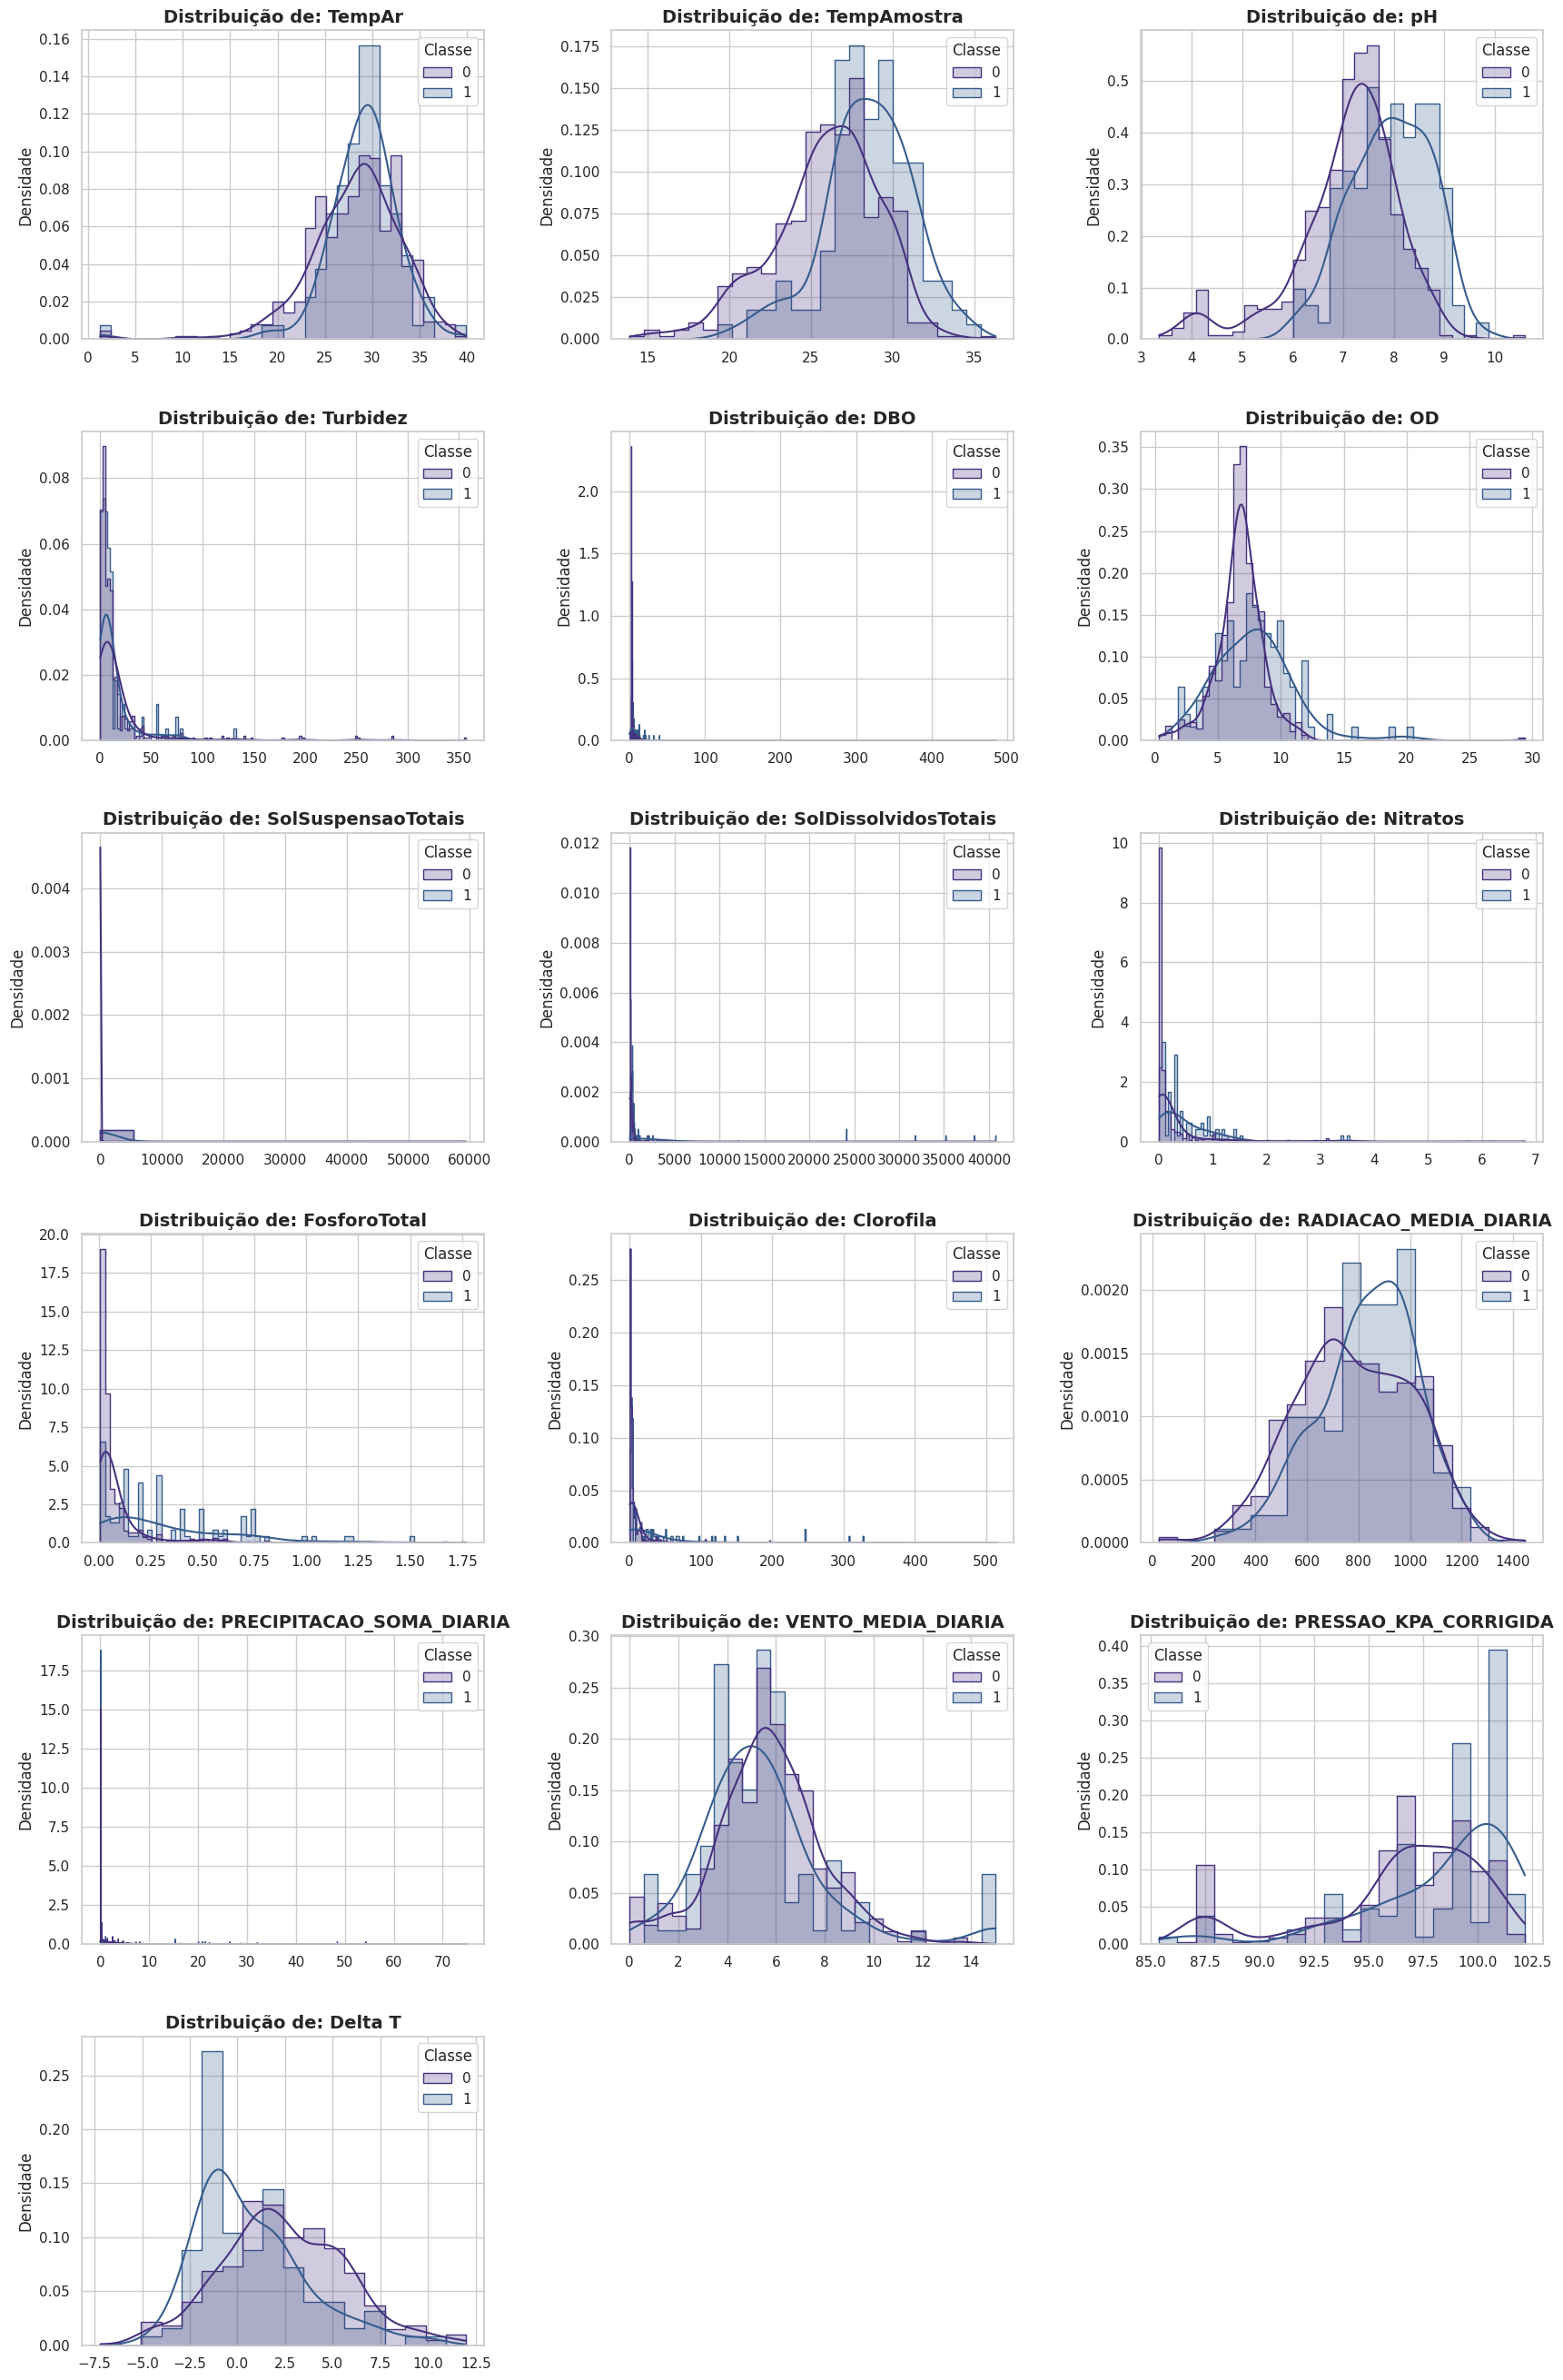


🎉 Gráficos gerados com sucesso!


In [ ]:
# ==============================================================================
# SELEÇÃO DE FEATURES PARA PLOTAR
# ==============================================================================
# Lista de todas as colunas fornecidas
all_columns = [
       'Latitude', 'Longitude', 'Date', 'Date_SISAGUA', 'Total_Cianobacterias',
       'Região Geográfica', 'UF', 'Município', 'Código IBGE',
       'Categoria do manancial superficial', 'Nome_Rio_sisagua',
       'Estacao_Codigo_split', 'Nome_Municipio', 'Ano', 'station_id',
       'data_inmet', 'fase', 'match_encontrado', 'TempAr', 'TempAmostra', 'pH',
       'Turbidez', 'DBO', 'OD', 'SolSuspensaoTotais', 'SolDissolvidosTotais',
       'Nitratos', 'FosforoTotal', 'Clorofila', 'distancia_m',
       'RADIACAO_MEDIA_DIARIA', 'PRECIPITACAO_SOMA_DIARIA',
       'VENTO_MEDIA_DIARIA', 'PRESSAO_MEDIA_DIARIA', 'Diferenca_Dias_Num',
       'Unidade_Conjunta', 'Num_Generos', 'Aphanocapsa_Count',
       'Outras_Cianobacterias', 'Classe', 'PRESSAO_KPA',
       'PRESSAO_KPA_CORRIGIDA', 'Verao', 'Outono', 'Inverno', 'Primavera',
       'Delta T'
]

# Lista de colunas a serem excluídas (categóricas, IDs, datas, flags binárias)
excluded_columns = [
    'Unidade_Conjunta', 'station_id', 'Código IBGE', 'Município', 'Estacao_Codigo_split', 'Região Geográfica', 'Ano', 'data_inmet', 'fase', 'match_encontrado', 'Date_SISAGUA',
    'UF', 'Nome_Municipio', 'Nome_Rio_sisagua', 'Categoria do manancial superficial', 'distancia_m', 'PRESSAO_KPA', 'PRESSAO_MEDIA_DIARIA', 'Num_Generos',
    'Date', 'Classe_final', 'Diferenca_Dias_Num', 'Latitude', 'Longitude', 'Outras_Cianobacterias', 'Aphanocapsa_Count', 'Total_Cianobacterias', # Excluir a própria classe e a data
    'Verao', 'Outono', 'Inverno', 'Primavera', 'Classe',# Excluir flags 0/1
]

# Filtra apenas as features que existem no DataFrame e não estão na lista de exclusão
features_to_plot = [
    col for col in all_columns
    if col in df_aphanocapsa_final_0e1.columns and col not in excluded_columns
]

print(f"📊 Features selecionadas para plotagem ({len(features_to_plot)}):")
print(features_to_plot)


# ==============================================================================
# GERAÇÃO DOS HISTOGRAMAS
# ==============================================================================
print("\n🖼️  Gerando os gráficos...")

# Definir o estilo dos gráficos
sns.set_theme(style="whitegrid", palette="viridis")

# Calcular o número de linhas e colunas para a grade de gráficos
n_features = len(features_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

# Criar a figura e os eixos
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()  # Transforma a matriz de eixos em um array 1D para facilitar o loop

# Loop para criar um histograma para cada feature
for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    sns.histplot(data=df_aphanocapsa_final_0e1, x=feature, hue='Classe', kde=True, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f'Distribuição de: {feature}', fontsize=14, weight='bold')
    ax.set_xlabel('') # Rótulos podem ficar poluídos, opcional remover
    ax.set_ylabel('Densidade') # Usando densidade para comparar formas

# Ocultar eixos que não foram usados (caso o número de features não seja múltiplo de n_cols)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Ajustar o layout para evitar sobreposição de títulos
plt.tight_layout(pad=3.0)
plt.show()

print("\n🎉 Gráficos gerados com sucesso!")


In [ ]:
df_aphanocapsa_final_0e1.to_csv('/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/2025 último teste/Aphanocapsa/DF-BASE_14D_Aphanocapsa.csv', index=False)

In [ ]:
df_aphanocapsa_final_0e1['Classe'].value_counts()

,count
Classe,
0,566
1,127


In [ ]:
len(df_aphanocapsa_final_0e1['Nome_Rio_sisagua'].unique())

54

In [ ]:
len(df_aphanocapsa_final_0e1['Município'].unique())

101

In [ ]:
df_aphanocapsa_final_0e1['UF'].unique()

array(['PR', 'SP', 'MG', 'ES', 'BA', 'PE', 'CE', 'GO'], dtype=object)

# **GRÁFICO PARA VER DADOS DO DATABASE**

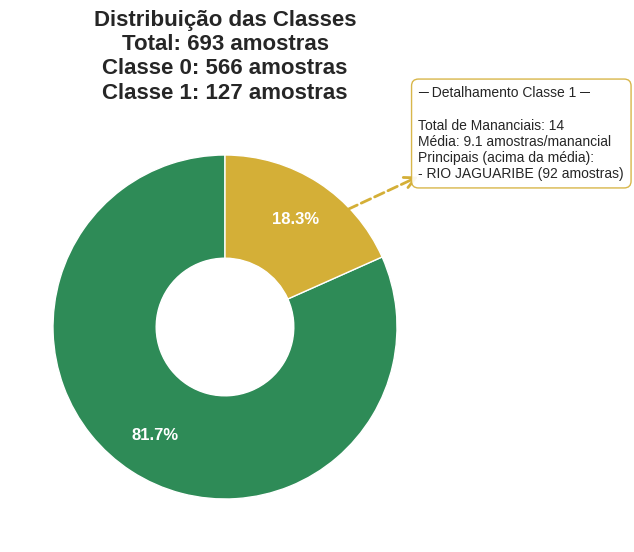

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch

# Dados
contagem_classes = df_aphanocapsa_final_0e1['Classe'].value_counts().sort_index()
total_amostras = len(df_aphanocapsa_final_0e1)

# Filtrar mananciais da Classe 1
mananciais_classe1 = df_aphanocapsa_final_0e1[df_aphanocapsa_final_0e1['Classe'] == 1]
contagem_mananciais = mananciais_classe1['Nome_Rio_sisagua'].value_counts()
total_mananciais_classe1 = len(contagem_mananciais)
media_amostras = contagem_mananciais.mean() if len(contagem_mananciais) > 0 else 0

# Configuração do estilo
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

# Cores
cores = ['#2E8B57', '#D4AF37']

# Gráfico de rosca
wedges, texts, autotexts = ax.pie(contagem_classes,
                                colors=cores,
                                startangle=90,
                                wedgeprops={'linewidth': 1, 'edgecolor': 'white', 'width': 0.6},
                                textprops={'fontsize': 11, 'fontweight': 'bold'},
                                autopct='%1.1f%%',
                                pctdistance=0.75)

# Círculo central
centre_circle = plt.Circle((0,0), 0.4, color='white', fc='white', linewidth=0)
ax.add_artist(centre_circle)

# Ajustar porcentagens
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Construir texto de informações
info_lines = [
    "─ Detalhamento Classe 1 ─",
    "",
    f"Total de Mananciais: {total_mananciais_classe1}",
    f"Média: {media_amostras:.1f} amostras/manancial",
    "Principais (acima da média):"
]

# Adicionar mananciais
max_chars = 20
for manancial, count in contagem_mananciais.items():
    if count >= media_amostras:
        manancial_str = f"- {manancial}" if len(manancial) <= max_chars else f"- {manancial[:max_chars-3]}..."
        info_lines.append(f"{manancial_str} ({count} amostras)")

text_box = ax.text(0.95, 0.95,
                 "\n".join(info_lines),
                 ha='left', va='center',
                 fontsize=10,
                 transform=ax.transAxes,
                 bbox=dict(facecolor='white', alpha=0.9,
                          edgecolor='#D4AF37', boxstyle='round,pad=0.5'))

# Adicionar seta conectando o setor da Classe 1 ao detalhamento
# Encontrar o ângulo médio do setor da Classe 1
theta1, theta2 = wedges[1].theta1, wedges[1].theta2
mid_angle = (theta1 + theta2)/2

# Converter ângulo para coordenadas
x = 0.6 * np.cos(np.deg2rad(mid_angle))
y = 0.6 * np.sin(np.deg2rad(mid_angle))

# Flecha
arrow = ConnectionPatch(xyA=(x, y), coordsA='data',
                        xyB=(0.95, 0.85), coordsB='axes fraction',
                        axesA=ax, axesB=ax,
                        arrowstyle='->', color='#D4AF37',
                        linewidth=2, linestyle='--',
                        mutation_scale=20)
ax.add_artist(arrow)

# Ajuste de layout
plt.tight_layout(pad=3.0)
fig.subplots_adjust(right=0.6)

# Título
plt.title('Distribuição das Classes\n'+
         f"Total: {total_amostras} amostras\n"+
         f"Classe 0: {contagem_classes[0]} amostras\n"+
         f"Classe 1: {contagem_classes[1]} amostras",
         fontsize=16, pad=10, fontweight='bold')


plt.savefig(r'/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/2025 último teste/Aphanocapsa'+
            r'/Distribuição de classes - 14D_Aphanocapsa.png', dpi=400, bbox_inches='tight')
plt.show()

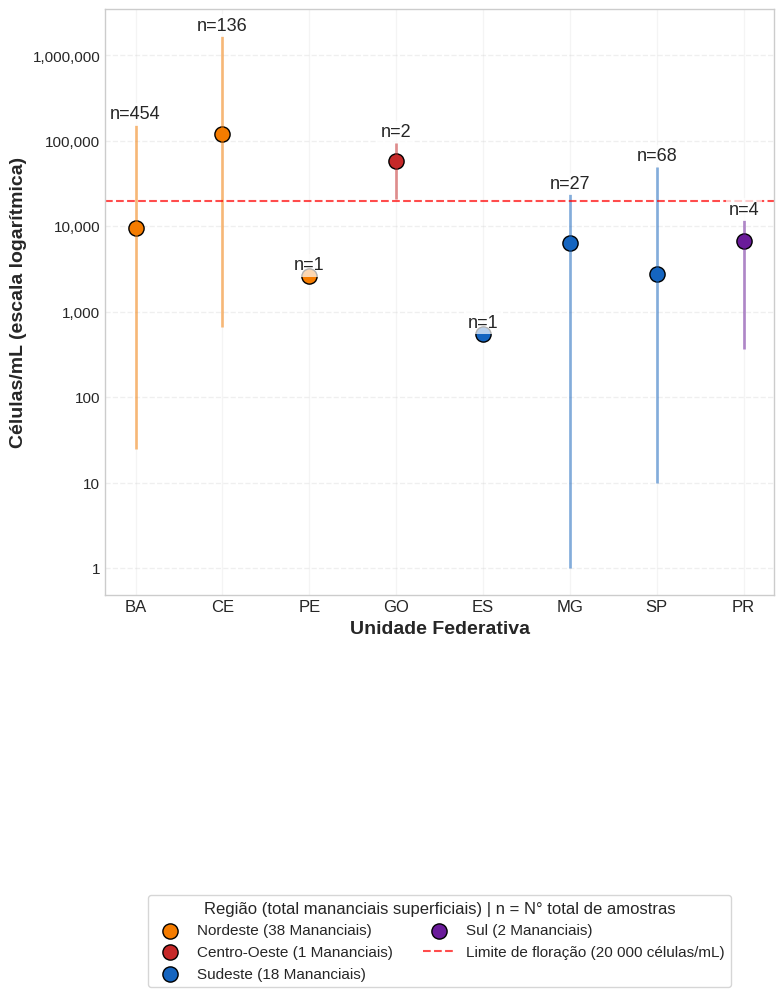

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Criar cópia temporária do dataframe
df_temp = df_aphanocapsa_final_0e1.copy()

# 2. Adicionar coluna temporária de região
uf_para_regiao = {
    'Norte': ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}

# Criar mapeamento inverso
regiao_map = {uf: regiao for regiao, ufs in uf_para_regiao.items() for uf in ufs}

df_temp['Região Geográfica'] = df_temp['UF'].map(regiao_map)

# 3. Calcular estatísticas
stats = df_temp.groupby(['UF', 'Região Geográfica'])['Total_Cianobacterias'].agg(
    ['mean', 'min', 'max', 'count']).reset_index()

# 4. Calcular número de municípios por região
contagem_mananciais = df_temp.groupby('Região Geográfica')['Nome_Rio_sisagua'].nunique()

# Substituir infinitos por NaN e depois remover
stats = stats.replace([np.inf, -np.inf], np.nan).dropna()

# 5. CORES BEM DISTINTAS PARA CADA REGIÃO
cores_regioes = {
    'Norte': '#2E7D32',        # Verde escuro (Amazônia)
    'Nordeste': '#F57C00',     # Laranja forte (Sol/Sertão)
    'Centro-Oeste': '#C62828', # Vermelho escuro (Cerrado)
    'Sudeste': '#1565C0',      # Azul escuro (Desenvolvimento)
    'Sul': '#6A1B9A'           # Roxo escuro (Diferenciação)
}

# 6. Criar figura
plt.figure(figsize=(8, 14))

lista_ufs = []

ordem_regioes = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
for i, regiao in enumerate(ordem_regioes):
    subset = stats[stats['Região Geográfica'] == regiao]
    valid  = subset[np.isfinite(subset['min']) & np.isfinite(subset['max'])]

    # --- acrescenta as siglas desta região, mantendo a ordem dos dados ---
    lista_ufs.extend(valid['UF'].unique())

    # Desenho - USAR CORES PERSONALIZADAS
    if len(valid):
        cor_regiao = cores_regioes[regiao]

        plt.vlines(x=valid['UF'], ymin=valid['min'], ymax=valid['max'],
                   colors=cor_regiao, alpha=0.5, linewidth=2)
        plt.scatter(valid['UF'], valid['mean'], s=120,
                    color=cor_regiao, edgecolor='black', linewidth=1,
                    label=f"{regiao} ({contagem_mananciais.get(regiao, 0)} Mananciais)")

# depois do loop
plt.xticks(ticks=np.arange(len(lista_ufs)), labels=lista_ufs, fontsize=12)

# Rotular UFs
ax  = plt.gca()
ax.set_xticks(np.arange(len(lista_ufs)))
ax.set_xticklabels(lista_ufs, fontsize=12)

# 7. Linha de referência horizontal
plt.axhline(20000, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Limite de floração (20 000 células/mL)')

# 8. Escalas e formatação
plt.yscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f}'))

# 9. Títulos e labels
plt.ylabel('Células/mL (escala logarítmica)', fontsize=14, weight='bold')
plt.xlabel('Unidade Federativa', fontsize=14, weight='bold')

# 10. Adicionar contagem de amostras
for _, row in stats.iterrows():
    if np.isfinite(row['mean']):
        plt.text(
            row['UF'],                                   # eixo x (categorias)
            row['max']*1.4 if np.isfinite(row['max'])    # eixo y (valor num.)
                else row['mean']*10,
            f"n={int(row['count'])}",
            ha='center',                                 # centraliza no x
            va='center_baseline',
            fontsize=13,
            bbox=dict(facecolor='white', alpha=0.7,
                      edgecolor='none', pad=2)
        )

# 11. Legenda personalizada
plt.legend(title='Região (total mananciais superficiais) | n = N° total de amostras',
          loc='upper center',          # Posiciona no centro superior
          bbox_to_anchor=(0.5, -0.5), # Coloca embaixo do gráfico
          frameon=True,
          framealpha=0.8,
          ncol=2)                     # Organiza em 2 colunas para economizar espaço

# 12. Grid e layout
plt.grid(True, axis='both', alpha=0.2)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Ajusta o espaço para a legenda embaixo

# 13. Salvar e mostrar
plt.savefig(r'/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/2025 último teste/Aphanocapsa'+
            r'/Aphanocapsa_14D_MAXminMédia_por_UF.png', dpi=400, bbox_inches='tight', transparent=False)
plt.show()

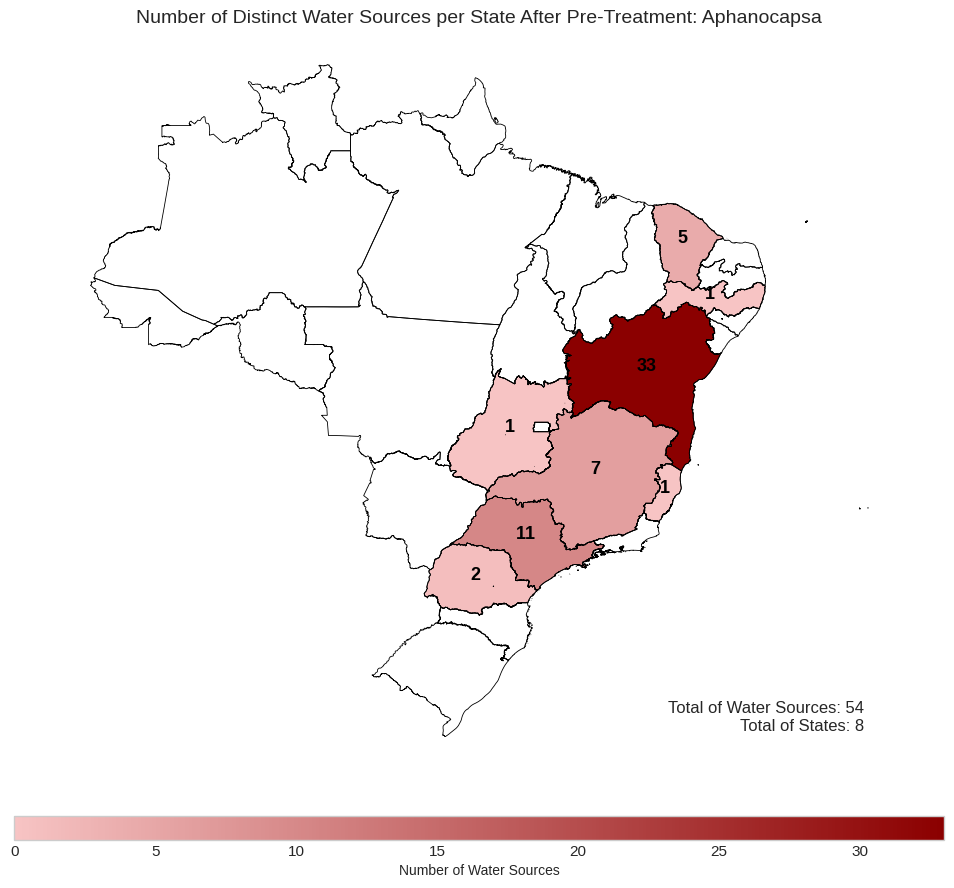

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Caminho para o shapefile
shapefile_path = "/content/drive/MyDrive/API HIDROWEB + SISAGUA CIANO/Códigos atuais/BR_UF_2022.shx"

# Carregar o shapefile
brasil = gpd.read_file(shapefile_path)

# Criar um GeoDataFrame com a coluna 'UF' para garantir consistência
siglas_estados = [
    'AC', 'AM', 'PA', 'RR', 'TO', 'MA', 'PI', 'CE', 'RN', 'PB',
    'PE', 'AL', 'SE', 'BA', 'MG', 'ES', 'RJ', 'SP', 'PR', 'SC',
    'RS', 'MS', 'MT', 'GO', 'DF', 'RO', 'AP'
]
brasil['UF'] = siglas_estados
selecionadas_groupby = [df_aphanocapsa_final_0e1]
i = 0
# Loop para gerar mapas por bactéria
for df_conjunto_x in selecionadas_groupby:
    # Definir gradientes de cor alternados
    if i == 0:
        cmap = LinearSegmentedColormap.from_list("vermelho_pastel", ["#f7c4c4", "#8b0000"])
    elif i==5:
        cmap = LinearSegmentedColormap.from_list("pessego_pastel", ["#ffe5b4", "#ffdab9"])
    elif i == 1:
        cmap = LinearSegmentedColormap.from_list("roxo_pastel", ["#e6e6fa", "#9370db"])
    elif i == 2:
        cmap = LinearSegmentedColormap.from_list("verde_pastel", ["#d9f2d9", "#77dd77"])
    elif i == 3:
        cmap = LinearSegmentedColormap.from_list("amarelo_pastel", ["#fff9c4", "#ffd700"])
    elif i == 4:
        cmap = LinearSegmentedColormap.from_list("azul_pastel", ["#E0FFFF", "#7FFFD4"])
    else:
        cmap = LinearSegmentedColormap.from_list("cinza_claro", ["#f2f2f2", "#d3d3d3"])

    # Contar mananciais distintos por UF
    mananciais_por_uf = df_conjunto_x.groupby('UF')['Nome_Rio_sisagua'].nunique().reset_index()
    mananciais_por_uf.columns = ['UF', 'Numero_Rios']

    # Juntar os dados ao GeoDataFrame do Brasil
    brasil_mapa = brasil.merge(mananciais_por_uf, on='UF', how='left')

    # Calcular o total de mananciais e UFs distintas
    total_mananciais = df_conjunto_x['Nome_Rio_sisagua'].nunique()
    total_ufs = df_conjunto_x['UF'].nunique()

    # Criar o mapa
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    brasil.boundary.plot(ax=ax, linewidth=0.6, edgecolor='black')  # Contornos
    brasil_mapa.plot(column='Numero_Rios', cmap=cmap, linewidth=0.6, ax=ax, edgecolor='black', legend=False)

    # Adicionar rótulos com os valores no centro dos estados
    for x, y, label in zip(brasil_mapa.geometry.centroid.x, brasil_mapa.geometry.centroid.y, brasil_mapa['Numero_Rios']):
        if not pd.isna(label):
            ax.text(x, y, str(int(label)), fontsize=13, ha='center', color='black', fontweight='bold')

    # Adicionar uma caixa de texto no canto inferior direito
    texto = f"Total of Water Sources: {total_mananciais}\nTotal of States: {total_ufs}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.7)
    ax.text(0.95, 0.05, texto, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

    # Legenda
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=brasil_mapa['Numero_Rios'].max()))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.05, aspect=40)
    cbar.set_label("Number of Water Sources", fontsize=10)

    # Título
    ax.axis('off')
    ax.set_title("Number of Distinct Water Sources per State After Pre-Treatment: Aphanocapsa", fontsize=14)
    i += 1

    # Mostrar o gráfico
    plt.show()